<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/main/RA1_LAB2/EXPERIENCIA_4%20/RA2_Lab_N%C2%B02_Exp4_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Experiencia 4: Segmentacion de grietas en estructuras de hormigon — U-Net


**Dataset:** Imagenes RGB de superficie de hormigon con mascaras binarias de grietas  
**Framework:** TensorFlow / Keras 3  
**Grupo:** G8  
**Fecha:** 05/2026


## 0. Configuracion del entorno

In [1]:
# ================== Descarga del dataset (Colab y LOCAL Windows/Linux) ==================
# Prioridad: (1) carpetas ya presentes, (2) zip local ya descargado, (3) descarga remota.
import os, sys, zipfile
from pathlib import Path

EN_COLAB = ('google.colab' in sys.modules) or os.path.isdir('/content')
BASE_DIR = Path('/content') if (EN_COLAB and os.path.isdir('/content')) else Path.cwd()
print(f'Entorno: {"Colab" if EN_COLAB else "local"}   BASE_DIR = {BASE_DIR}')

ZIP_DATASET = BASE_DIR / 'concreto_agrietado_segmentacion.zip'
URL_DATASET = ('https://drive.google.com/uc?export=download'
               '&id=1MMQXhR3-Q0xSFskI7lC8mEhywkzTlhVc&confirm=t')

def _descargar(url, destino, minimo_bytes=1_000_000):
    """Descarga url -> destino. Intenta urllib (portable) y luego wget (Linux/Colab).
    Devuelve True si el archivo resultante supera minimo_bytes."""
    destino = Path(destino)
    try:
        import urllib.request
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=120) as r, open(destino, 'wb') as f:
            while True:
                chunk = r.read(1 << 20)
                if not chunk:
                    break
                f.write(chunk)
    except Exception as e:
        print(f'  urllib fallo ({type(e).__name__}: {e}); intentando wget...')
        try:
            import subprocess
            subprocess.run(['wget', '-q', '-c', '--no-check-certificate',
                            url, '-O', str(destino)], check=False)
        except Exception as e2:
            print(f'  wget no disponible ({type(e2).__name__}: {e2}).')
    ok = destino.exists() and destino.stat().st_size > minimo_bytes
    if not ok and destino.exists():
        destino.unlink()
    return ok

if (BASE_DIR / 'cracks').exists() and (BASE_DIR / 'labels').exists():
    print('Dataset ya disponible.')
else:
    if not (ZIP_DATASET.exists() and zipfile.is_zipfile(ZIP_DATASET)):
        print('Descargando dataset...')
        _descargar(URL_DATASET, ZIP_DATASET)
    if ZIP_DATASET.exists() and zipfile.is_zipfile(ZIP_DATASET):
        with zipfile.ZipFile(ZIP_DATASET) as z:
            z.extractall(BASE_DIR)
        print('Dataset descomprimido.')
    else:
        print('AVISO: no se pudo obtener el dataset automaticamente.')
        print(f'       Descargar manualmente y colocar el zip en: {ZIP_DATASET}')
        print(f'       o descomprimir las carpetas cracks/ y labels/ dentro de {BASE_DIR}')


Entorno: Colab   BASE_DIR = /content
Descargando dataset...
Dataset descomprimido.


In [2]:
import tensorflow as tf
import keras
print(f'TensorFlow: {tf.__version__}')
print(f'Keras:      {keras.__version__}')
assert int(keras.__version__.split('.')[0]) >= 3, 'Este notebook requiere Keras 3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re, cv2, os, glob, time, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from typing import List
from keras import layers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE   = 256
N_CHANNELS = 1
BATCH_SIZE = 8
MASK_THR   = 0.5

FIG_DIR = Path('figuras_informe')
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'savefig.bbox': 'tight',
    'savefig.dpi': 150,
})

def guardar(fig, nombre):
    fig.savefig(FIG_DIR / f'{nombre}.png')

print('Entorno configurado.')


TensorFlow: 2.20.0
Keras:      3.13.2
Entorno configurado.


In [3]:
# ================== DIRECTIVA 0 — Infraestructura de reporte ==================
# Registro central de metricas + guardado dual de figuras + trazabilidad de entorno.
import json, platform, sys, time
from pathlib import Path

T0_NOTEBOOK = time.time()          # cronometro global (ver celda final)

FIGS_DIR = Path('figs'); FIGS_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)       # 'figuras_informe', ya definido en la celda anterior

# Convencion unica de tamano en disco para TODO el trabajo (Directiva g)
BYTES_POR_MB = 1e6                 # 1 MB = 1e6 bytes (SI), NO 2**20

METRICAS = {}                      # dict plano nombre -> valor

def reg(nombre, valor, dec=4):
    """Registra una metrica reportable. Redondea floats a 4 decimales."""
    try:
        if isinstance(valor, (bool, str)) or valor is None:
            METRICAS[nombre] = valor
        elif isinstance(valor, (int,)):
            METRICAS[nombre] = int(valor)
        else:
            v = float(valor)
            METRICAS[nombre] = round(v, dec)
    except (TypeError, ValueError):
        METRICAS[nombre] = str(valor)
    return valor

# Sobrescribe la version de la celda anterior: ahora guarda en los dos destinos.
def guardar(fig, nombre):
    fig.savefig(FIG_DIR  / f'{nombre}.png',       dpi=150, bbox_inches='tight')
    fig.savefig(FIGS_DIR / f'exp4_{nombre}.png',  dpi=200, bbox_inches='tight')
    return str(FIGS_DIR / f'exp4_{nombre}.png')

# --- Entorno: acelerador realmente detectado (no asumido) ---
_gpus = tf.config.list_physical_devices('GPU')
if _gpus:
    try:
        _det = tf.config.experimental.get_device_details(_gpus[0])
        ACELERADOR = f"GPU: {_det.get('device_name', 'desconocida')}"
    except Exception:
        ACELERADOR = f'GPU: {len(_gpus)} dispositivo(s)'
else:
    ACELERADOR = 'CPU (sin GPU detectada)'

ENTORNO = {
    'python':      sys.version.split()[0],
    'tensorflow':  tf.__version__,
    'keras':       keras.__version__,
    'numpy':       np.__version__,
    'pandas':      pd.__version__,
    'opencv':      cv2.__version__,
    'matplotlib':  __import__('matplotlib').__version__,
    'plataforma':  platform.platform(),
    'acelerador':  ACELERADOR,
    'seed':        SEED,
}
print('=== ENTORNO DE EJECUCION ===')
for k, v in ENTORNO.items():
    print(f'  {k:<12}: {v}')
print(f'  bytes/MB    : {BYTES_POR_MB:.0e}  (1 MB = 1e6 bytes en todo el trabajo)')


=== ENTORNO DE EJECUCION ===
  python      : 3.12.13
  tensorflow  : 2.20.0
  keras       : 3.13.2
  numpy       : 2.0.2
  pandas      : 2.2.2
  opencv      : 5.0.0
  matplotlib  : 3.10.0
  plataforma  : Linux-6.6.122+-x86_64-with-glibc2.35
  acelerador  : GPU: Tesla T4
  seed        : 42
  bytes/MB    : 1e+06  (1 MB = 1e6 bytes en todo el trabajo)



---



## 1. Carga y estructura del dataset

In [4]:
# BASE_DIR viene de la celda de descarga; si no existe se infiere (Colab o local).
DATA_ROOT = Path(globals().get(
    'BASE_DIR',
    Path('/content') if Path('/content/cracks').exists() else Path.cwd()))
IMG_DIR   = DATA_ROOT / 'cracks'
MASK_DIR  = DATA_ROOT / 'labels'

for d in [IMG_DIR, MASK_DIR]:
    if not d.exists():
        print(f'AVISO: {d} no encontrado')

img_paths      = sorted(glob.glob(str(IMG_DIR / '*.jpg')) + glob.glob(str(IMG_DIR / '*.png')))
mask_paths_all = sorted(glob.glob(str(MASK_DIR / '*')))

stems_img  = {Path(p).stem for p in img_paths}
stems_mask = {Path(p).stem for p in mask_paths_all}
sin_mascara = stems_img - stems_mask
sin_imagen  = stems_mask - stems_img

print(f'Raiz de datos:         {DATA_ROOT}')
print(f'Imagenes encontradas:  {len(img_paths)}')
print(f'Mascaras encontradas:  {len(mask_paths_all)}')
print(f'Imagenes sin mascara:  {len(sin_mascara)}')
print(f'Mascaras sin imagen:   {len(sin_imagen)}')


Raiz de datos:         /content
Imagenes encontradas:  410
Mascaras encontradas:  410
Imagenes sin mascara:  0
Mascaras sin imagen:   0



---



## 2. Exploracion y auditoria del dataset

Antes de diseñar ninguna arquitectura, se audita la calidad del dataset. El etiquetado fue realizado por un equipo externo; la calidad de las mascaras condiciona el techo de desempeno del modelo: entrenar sobre etiquetas incorrectas produce un modelo que aprende el error del anotador, no la geometria de la grieta.

Se examinan cuatro aspectos:
1. Distribucion del desbalance de clases (fraccion de pixeles de grieta por imagen).
2. Alineamiento visual imagen-mascara.
3. Consistencia del color utilizado para la clase grieta.
4. Casos anomalos: mascaras vacias, mascaras que cubren toda la imagen.


In [5]:
def estadisticas_dataset(img_paths, mask_dir):
    tamanios, crack_fracs, colores_grieta = [], [], []
    for p in img_paths:
        stem = Path(p).stem
        img  = cv2.imread(p)
        if img is not None:
            tamanios.append(img.shape[:2])
        mp = Path(mask_dir) / (stem + '.png')
        if mp.exists():
            m = cv2.imread(str(mp))
            if m is not None:
                mg = cv2.cvtColor(m, cv2.COLOR_BGR2GRAY)
                crack_fracs.append((mg > 100).mean())
                no_neg = m.reshape(-1, 3)
                no_neg = no_neg[no_neg.max(axis=1) > 50]
                if len(no_neg):
                    colores_grieta.append(no_neg.mean(axis=0))
            else:
                crack_fracs.append(0.0)
        else:
            crack_fracs.append(0.0)
    return (np.array(tamanios), np.array(crack_fracs),
            np.array(colores_grieta) if colores_grieta else np.zeros((1, 3)))

if len(img_paths) > 0:
    tamanios, crack_fracs, colores_grieta = estadisticas_dataset(img_paths, MASK_DIR)

    print('=== Estadisticas del dataset ===')
    print(f'  Total imagenes:            {len(img_paths)}')
    print(f'  Tamanos H: [{tamanios[:,0].min()} - {tamanios[:,0].max()}]  '
          f'W: [{tamanios[:,1].min()} - {tamanios[:,1].max()}]')
    print(f'  Fraccion grieta media:     {crack_fracs.mean()*100:.2f}%')
    print(f'  P10={np.percentile(crack_fracs,10)*100:.1f}%  '
          f'P50={np.percentile(crack_fracs,50)*100:.1f}%  '
          f'P90={np.percentile(crack_fracs,90)*100:.1f}%')
    print(f'  Imagenes con <0.1% grieta: {(crack_fracs<0.001).sum()}')
    print(f'  Imagenes con >50% grieta:  {(crack_fracs>0.5).sum()}')
    print()

    # ---------- CORRECCION (c): la alarma se condiciona al valor REAL ----------
    # Bug original: `colores_grieta.std() > 30` usaba la std del arreglo aplanado
    # (mezcla de canales). Con color constante (64,128,64) eso da ~30.2 y disparaba
    # la alarma aun con std POR CANAL = 0.0. Ahora se evalua la dispersion ENTRE
    # MASCARAS, canal por canal, que es lo que mide inconsistencia entre anotadores.
    std_por_canal  = colores_grieta.std(axis=0)          # shape (3,) -> B, G, R
    std_max_canal  = float(std_por_canal.max())
    UMBRAL_STD_COLOR = 30.0                              # criterio explicito

    print('=== Auditoria de color en mascaras ===')
    print(f'  Mascaras con pixeles de grieta: {len(colores_grieta)}')
    print(f'  Color medio de grieta (B,G,R): '
          f'({colores_grieta[:,0].mean():.0f}, {colores_grieta[:,1].mean():.0f}, '
          f'{colores_grieta[:,2].mean():.0f})')
    print(f'  Desv. std ENTRE mascaras: B={std_por_canal[0]:.2f}  '
          f'G={std_por_canal[1]:.2f}  R={std_por_canal[2]:.2f}   '
          f'(max={std_max_canal:.2f}, umbral={UMBRAL_STD_COLOR:.0f})')
    if std_max_canal > UMBRAL_STD_COLOR:
        print(f'  ATENCION: alta variabilidad de color entre mascaras '
              f'(std max {std_max_canal:.2f} > {UMBRAL_STD_COLOR:.0f}) '
              f'-> posible inconsistencia entre anotadores.')
    else:
        print(f'  Color CONSISTENTE entre mascaras (std max {std_max_canal:.2f} '
              f'<= {UMBRAL_STD_COLOR:.0f}): las mascaras fueron generadas con un '
              f'unico valor de color, no hay evidencia de multiples anotadores.')

    # ---------- Margen del umbral de binarizacion (> 100 en gris) ----------
    # Riesgo real detectado: el color de grieta (64,128,64) BGR pasa a gris como
    # 0.299*R + 0.587*G + 0.114*B, muy cerca del umbral 100 que usa todo el pipeline.
    gris_equiv = float(0.299*colores_grieta[:,2].mean() +
                       0.587*colores_grieta[:,1].mean() +
                       0.114*colores_grieta[:,0].mean())
    print()
    print(f'  Gris equivalente del color de grieta: {gris_equiv:.1f}  '
          f'(umbral del pipeline: >100)')
    print(f'  Margen: {gris_equiv-100:+.1f} niveles.')
    if gris_equiv - 100 < 15:
        print('  ADVERTENCIA: el margen es estrecho. Cualquier recompresion JPEG o '
              'cambio de color de anotacion puede vaciar las mascaras silenciosamente. '
              'Se documenta como riesgo de fragilidad del preprocesamiento.')

    reg('audit_color_std_max_entre_mascaras', std_max_canal)
    reg('audit_color_gris_equivalente',       gris_equiv, dec=1)
    reg('audit_color_margen_umbral100',       gris_equiv - 100, dec=1)
    reg('eda_frac_grieta_media_pct',          crack_fracs.mean()*100)
    reg('eda_frac_grieta_p10_pct',            np.percentile(crack_fracs,10)*100)
    reg('eda_frac_grieta_p50_pct',            np.percentile(crack_fracs,50)*100)
    reg('eda_frac_grieta_p90_pct',            np.percentile(crack_fracs,90)*100)


=== Estadisticas del dataset ===
  Total imagenes:            410
  Tamanos H: [227 - 227]  W: [227 - 227]
  Fraccion grieta media:     9.91%
  P10=4.2%  P50=8.9%  P90=16.3%
  Imagenes con <0.1% grieta: 0
  Imagenes con >50% grieta:  0

=== Auditoria de color en mascaras ===
  Mascaras con pixeles de grieta: 410
  Color medio de grieta (B,G,R): (64, 128, 64)
  Desv. std ENTRE mascaras: B=0.00  G=0.00  R=0.00   (max=0.00, umbral=30)
  Color CONSISTENTE entre mascaras (std max 0.00 <= 30): las mascaras fueron generadas con un unico valor de color, no hay evidencia de multiples anotadores.

  Gris equivalente del color de grieta: 101.6  (umbral del pipeline: >100)
  Margen: +1.6 niveles.
  ADVERTENCIA: el margen es estrecho. Cualquier recompresion JPEG o cambio de color de anotacion puede vaciar las mascaras silenciosamente. Se documenta como riesgo de fragilidad del preprocesamiento.


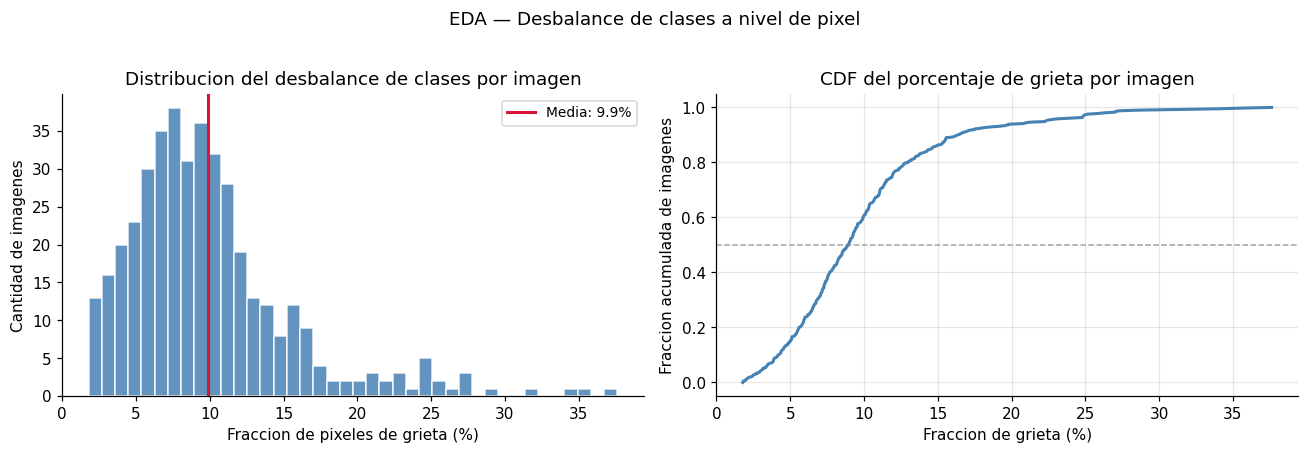

In [6]:
if len(img_paths) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(crack_fracs * 100, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0].axvline(crack_fracs.mean()*100, color='crimson', lw=2,
                    label=f'Media: {crack_fracs.mean()*100:.1f}%')
    axes[0].set_xlabel('Fraccion de pixeles de grieta (%)')
    axes[0].set_ylabel('Cantidad de imagenes')
    axes[0].set_title('Distribucion del desbalance de clases por imagen')
    axes[0].legend(fontsize=9)

    sorted_cf = np.sort(crack_fracs) * 100
    axes[1].plot(sorted_cf, np.linspace(0, 1, len(sorted_cf)), 'steelblue', lw=2)
    axes[1].axhline(0.5, color='gray', lw=1, linestyle='--', alpha=0.7)
    axes[1].set_xlabel('Fraccion de grieta (%)')
    axes[1].set_ylabel('Fraccion acumulada de imagenes')
    axes[1].set_title('CDF del porcentaje de grieta por imagen')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('EDA — Desbalance de clases a nivel de pixel', fontsize=12, y=1.02)
    plt.tight_layout()
    guardar(fig, '01_eda_desbalance')
    plt.show()


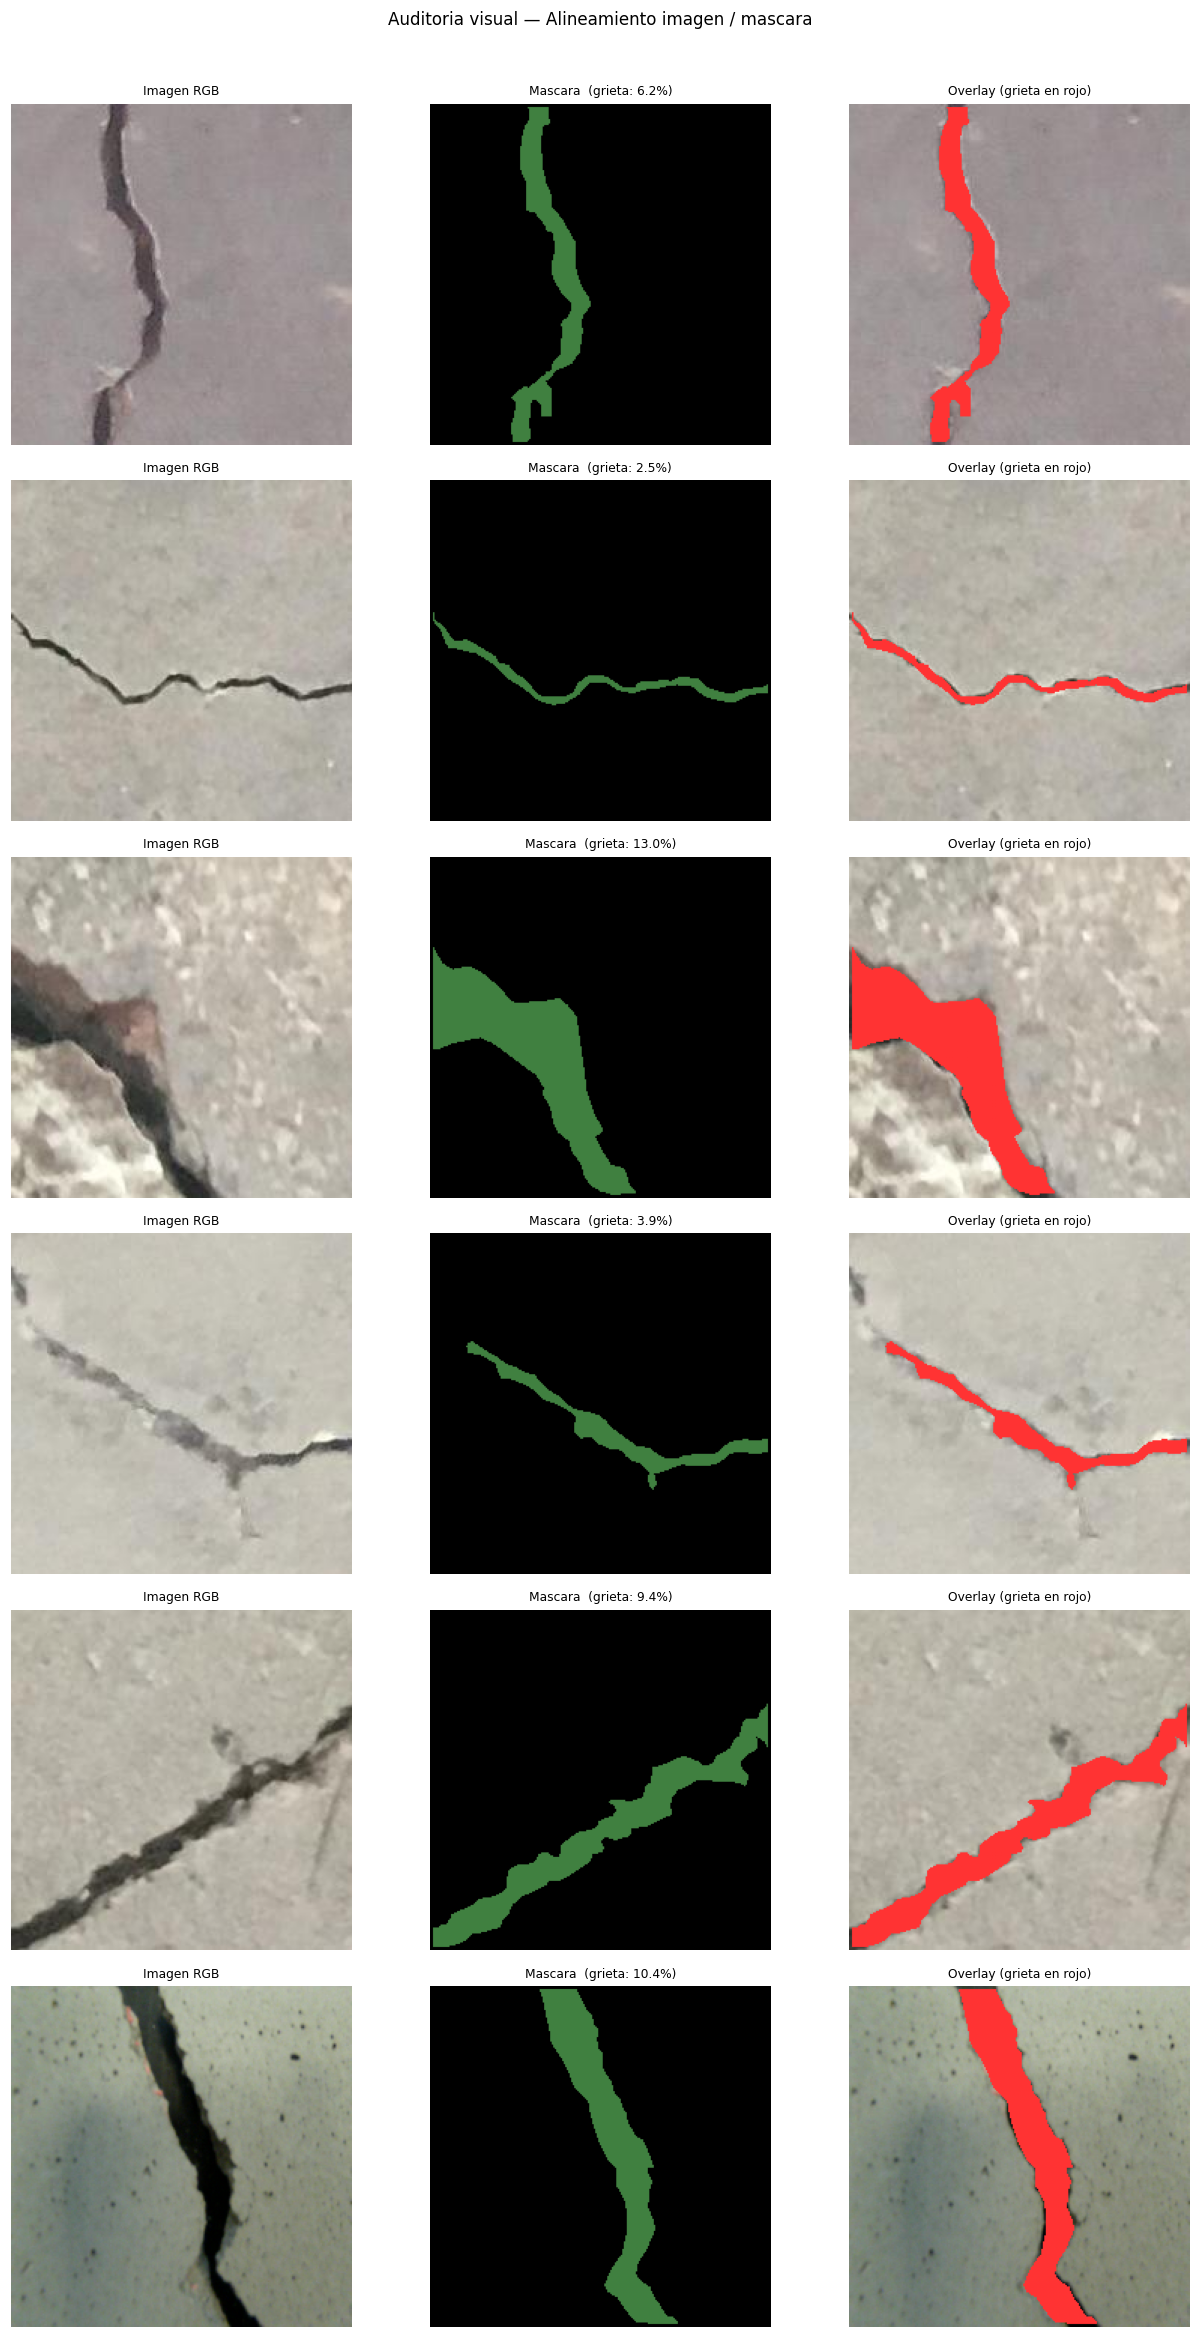

In [7]:
if len(img_paths) > 0:
    n_show = min(6, len(img_paths))
    indices = np.linspace(0, len(img_paths)-1, n_show, dtype=int)

    fig, axes = plt.subplots(n_show, 3, figsize=(12, 3.5*n_show))

    for row, idx in enumerate(indices):
        p    = img_paths[idx]
        stem = Path(p).stem
        img_bgr = cv2.imread(p)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        mp = MASK_DIR / (stem + '.png')
        mask_color = cv2.imread(str(mp)) if mp.exists() else None
        mask_gray  = cv2.cvtColor(mask_color, cv2.COLOR_BGR2GRAY) if mask_color is not None else np.zeros(img_rgb.shape[:2])
        overlay = img_rgb.copy().astype(np.float32) / 255.0
        grieta_px = mask_gray > 100
        overlay[grieta_px, 0] = 1.0
        overlay[grieta_px, 1] = 0.2
        overlay[grieta_px, 2] = 0.2
        axes[row, 0].imshow(img_rgb)
        axes[row, 0].set_title(f'Imagen RGB', fontsize=8)
        axes[row, 1].imshow(mask_color[:,:,::-1] if mask_color is not None else mask_gray,
                            cmap=None if mask_color is not None else 'gray')
        axes[row, 1].set_title(f'Mascara  (grieta: {grieta_px.mean()*100:.1f}%)', fontsize=8)
        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title('Overlay (grieta en rojo)', fontsize=8)
        for ax in axes[row]: ax.axis('off')

    plt.suptitle('Auditoria visual — Alineamiento imagen / mascara', fontsize=11, y=1.01)
    plt.tight_layout()
    guardar(fig, '02_auditoria_visual')
    plt.show()


=== AUDITORIA DE ETIQUETAS - evidencia cuantitativa ===
  Pares imagen-mascara auditados: 410

  (i) IoU mascara vs proxy geometrico (Otsu invertido + apertura):
      media=0.7473  P10=0.5977  P50=0.7838  P90=0.8679
      pares con IoU_proxy < 0.20: 6

  (ii) Intensidad media bajo la mascara vs fuera (grieta = mas oscura):
      dentro=85.2  fuera=168.9  contraste medio=83.6 niveles
      pares con contraste <= 0 (mascara NO mas oscura que el fondo): 0
      pares con contraste < 20: 0

  (iii) Grosor medio mascara vs proxy (distance transform):
      grosor mascara=10.41 px  proxy=9.63 px  ratio medio=1.08
      pares con ratio > 1.5 (mascara posiblemente DILATADA): 27

  --- TOP 10 CANDIDATOS A ETIQUETA RUIDOSA (mayor discordancia) ---
   #  stem                      IoUprx   contr  ratioG   %mask   score
  ------------------------------------------------------------------------
   1  01648                      0.379    39.6    2.69  34.15%   1.098
   2  02691                      0

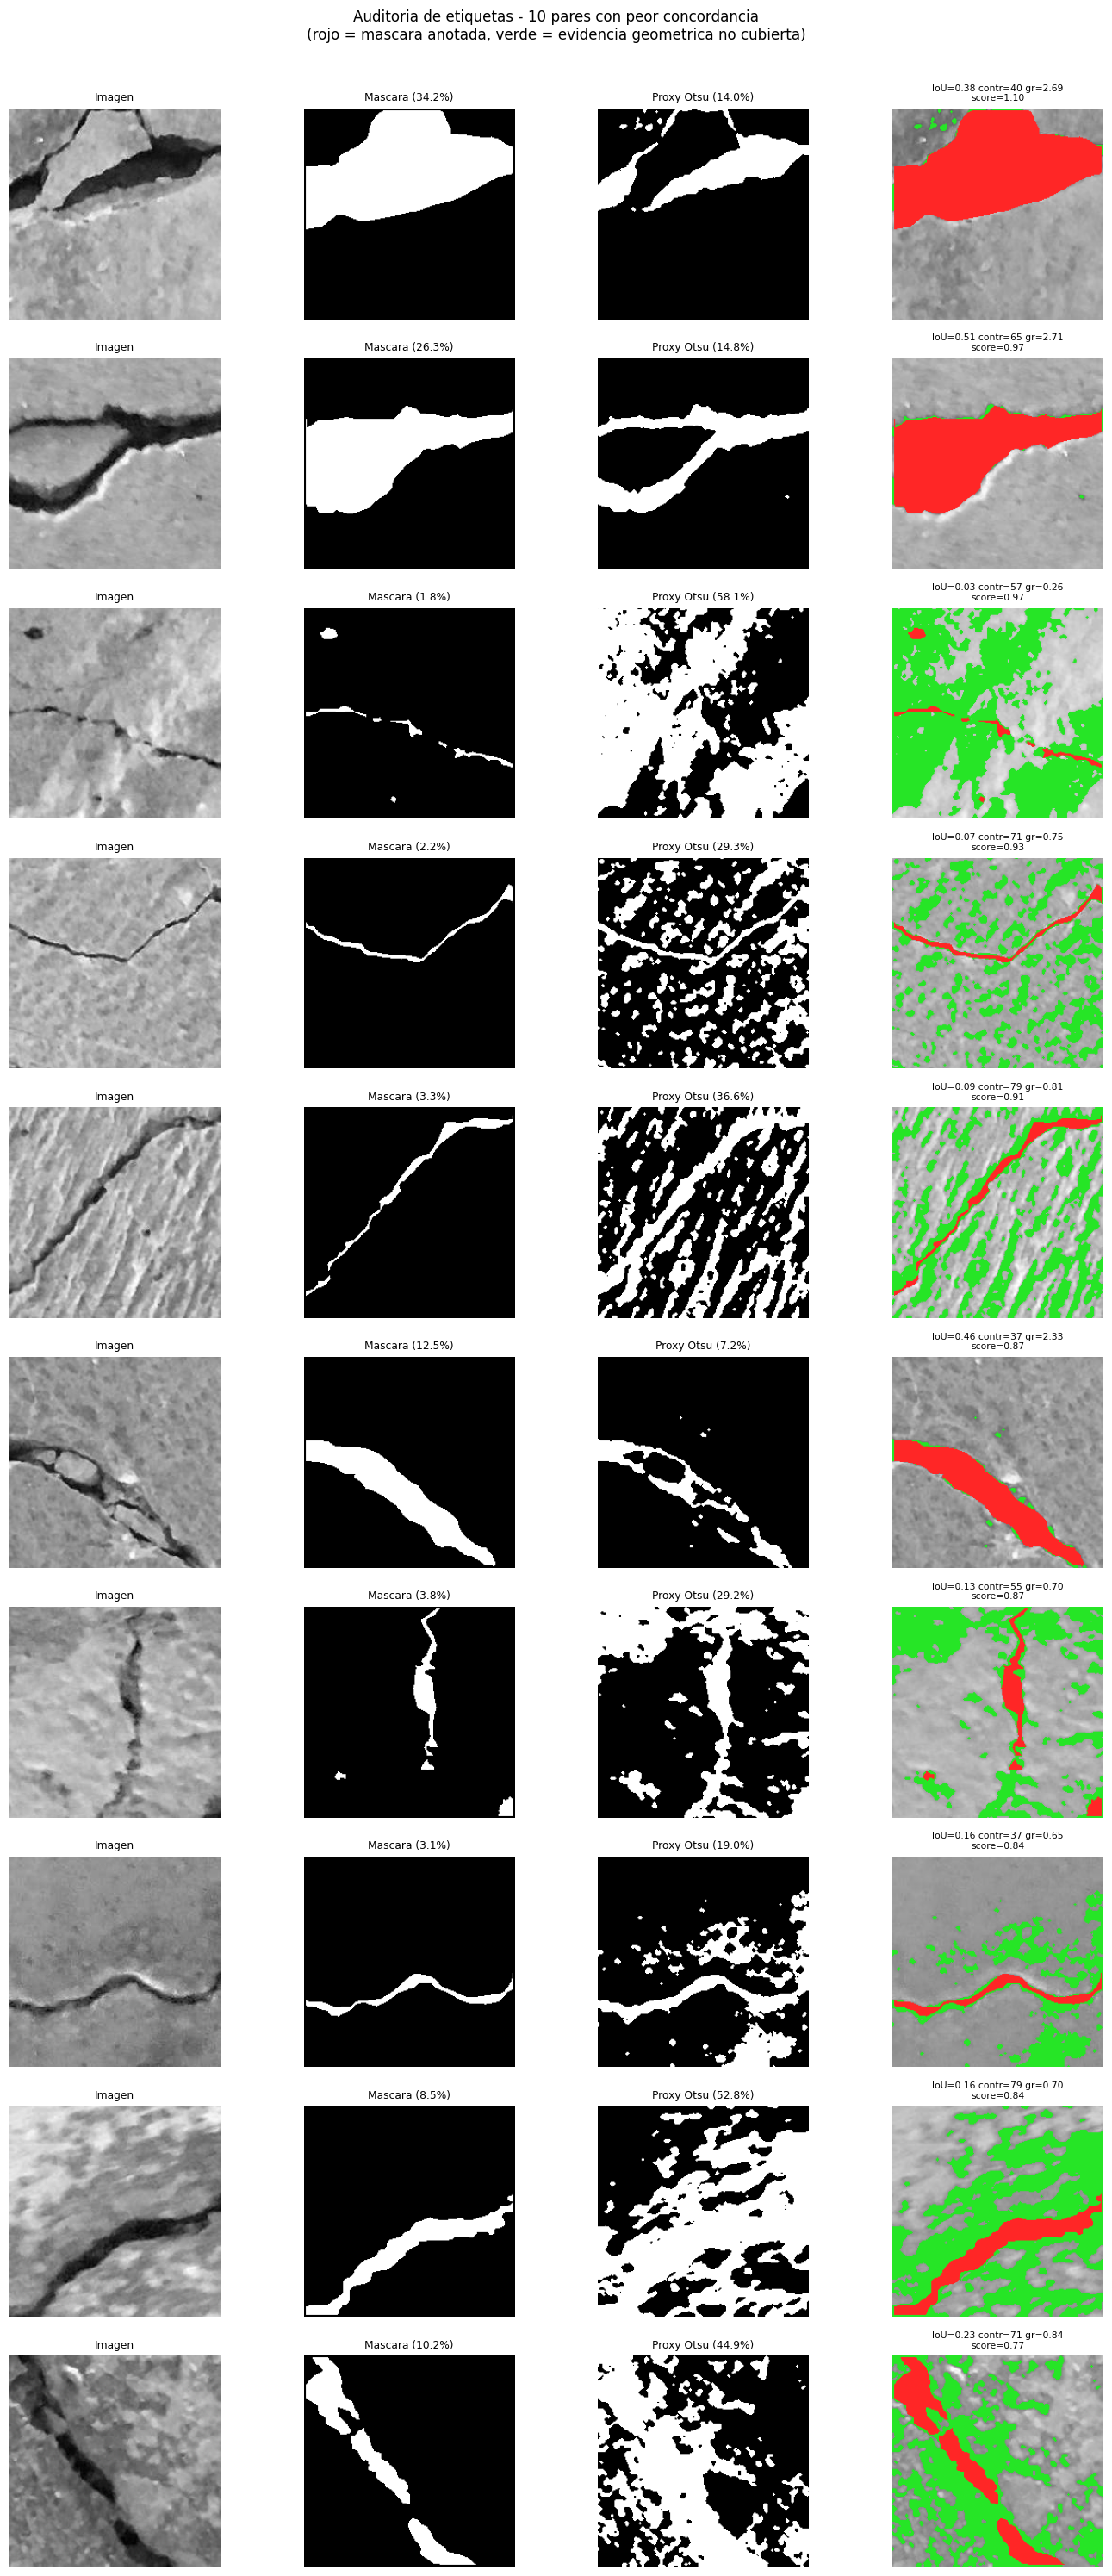

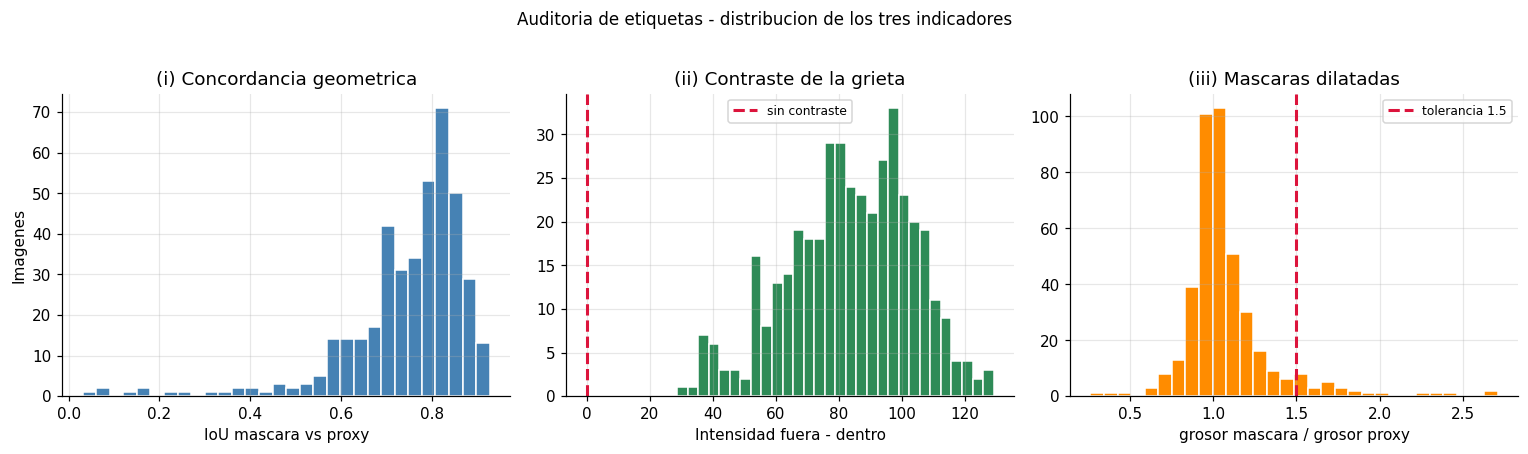


NOTA METODOLOGICA: el proxy de Otsu no es verdad de terreno; es una referencia
no supervisada. Un IoU bajo indica DISCREPANCIA a investigar, no necesariamente
un error de etiquetado. El cruce con el IoU del modelo en test (celda posterior)
es lo que convierte la discrepancia en evidencia.


In [8]:
# ============ (d) AUDITORIA DE ETIQUETAS BASADA EN EVIDENCIA ============
# Reemplaza la auditoria anterior (que solo contaba mascaras vacias -> 0 hallazgos).
# Para cada par imagen/mascara calcula:
#   (i)   IoU entre la mascara y un proxy geometrico de grieta (Otsu invertido + apertura)
#   (ii)  intensidad media BAJO la mascara vs FUERA de ella (contraste; una grieta real
#         es MAS OSCURA que el fondo -> contraste positivo y grande)
#   (iii) grosor medio (distance transform) de la mascara vs grosor del proxy
#         (ratio >> 1 indica mascara dilatada respecto de la grieta fisica)
# NOTA: se usa cv2.distanceTransform; NO se requiere SciPy.

def proxy_geometrico_grieta(img_gray, ksize=3):
    """Proxy no supervisado de grieta: Otsu invertido + apertura morfologica."""
    sup = cv2.GaussianBlur(img_gray, (3, 3), 0)
    _, th = cv2.threshold(sup, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    k  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, k, iterations=1)
    return (th > 0).astype(np.uint8)

def grosor_medio(mask_bin):
    """Grosor medio = 2 * media de la distancia al borde dentro de la region."""
    if mask_bin.sum() == 0:
        return 0.0
    dt = cv2.distanceTransform(mask_bin.astype(np.uint8), cv2.DIST_L2, 5)
    return float(2.0 * dt[mask_bin > 0].mean())

def _iou_bin(a, b):
    a = a.astype(bool); b = b.astype(bool)
    u = np.logical_or(a, b).sum()
    return float(np.logical_and(a, b).sum() / u) if u > 0 else 1.0

if len(img_paths) > 0:
    filas = []
    for p in img_paths:
        stem = Path(p).stem
        img_g = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        mp    = MASK_DIR / (stem + '.png')
        if img_g is None or not mp.exists():
            continue
        m_g = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
        if m_g is None:
            continue
        if m_g.shape != img_g.shape:
            m_g = cv2.resize(m_g, (img_g.shape[1], img_g.shape[0]),
                             interpolation=cv2.INTER_NEAREST)
        mask = (m_g > 100).astype(np.uint8)
        prox = proxy_geometrico_grieta(img_g)

        # (i) concordancia geometrica
        iou_proxy = _iou_bin(mask, prox)

        # (ii) contraste dentro/fuera de la mascara
        dentro = img_g[mask > 0]
        fuera  = img_g[mask == 0]
        int_dentro = float(dentro.mean()) if dentro.size else np.nan
        int_fuera  = float(fuera.mean())  if fuera.size  else np.nan
        contraste  = (int_fuera - int_dentro) if dentro.size and fuera.size else np.nan

        # (iii) grosor mascara vs grosor proxy
        g_mask  = grosor_medio(mask)
        g_prox  = grosor_medio(prox)
        ratio_g = (g_mask / g_prox) if g_prox > 1e-6 else np.nan

        filas.append({
            'stem': stem, 'path': p,
            'frac_mask': float(mask.mean()),
            'frac_proxy': float(prox.mean()),
            'iou_proxy': iou_proxy,
            'int_dentro': int_dentro, 'int_fuera': int_fuera, 'contraste': contraste,
            'grosor_mask': g_mask, 'grosor_proxy': g_prox, 'ratio_grosor': ratio_g,
        })

    df_audit = pd.DataFrame(filas)

    # ---- Score de discordancia (mayor = peor). Pesos explicitos y documentados ----
    CONTRASTE_ESPERADO = 20.0   # niveles de gris: una grieta real es al menos ~20 mas oscura
    RATIO_TOLERADO     = 1.5    # hasta 1.5x el grosor del proxy se considera aceptable
    _contr = df_audit['contraste'].fillna(0.0)
    _ratio = df_audit['ratio_grosor'].fillna(1.0)
    df_audit['pen_iou']      = 1.0 - df_audit['iou_proxy']
    df_audit['pen_contrast'] = (1.0 - (_contr / CONTRASTE_ESPERADO)).clip(lower=0.0, upper=1.0)
    df_audit['pen_grosor']   = (_ratio - RATIO_TOLERADO).clip(lower=0.0) / RATIO_TOLERADO
    df_audit['discordancia'] = (1.0 * df_audit['pen_iou'] +
                                0.6 * df_audit['pen_contrast'] +
                                0.6 * df_audit['pen_grosor'])
    df_audit = df_audit.sort_values('discordancia', ascending=False).reset_index(drop=True)

    print('=== AUDITORIA DE ETIQUETAS - evidencia cuantitativa ===')
    print(f'  Pares imagen-mascara auditados: {len(df_audit)}')
    print()
    print('  (i) IoU mascara vs proxy geometrico (Otsu invertido + apertura):')
    print(f'      media={df_audit["iou_proxy"].mean():.4f}  '
          f'P10={df_audit["iou_proxy"].quantile(0.10):.4f}  '
          f'P50={df_audit["iou_proxy"].median():.4f}  '
          f'P90={df_audit["iou_proxy"].quantile(0.90):.4f}')
    print(f'      pares con IoU_proxy < 0.20: {(df_audit["iou_proxy"]<0.20).sum()}')
    print()
    print('  (ii) Intensidad media bajo la mascara vs fuera (grieta = mas oscura):')
    print(f'      dentro={df_audit["int_dentro"].mean():.1f}  '
          f'fuera={df_audit["int_fuera"].mean():.1f}  '
          f'contraste medio={df_audit["contraste"].mean():.1f} niveles')
    print(f'      pares con contraste <= 0 (mascara NO mas oscura que el fondo): '
          f'{(df_audit["contraste"]<=0).sum()}')
    print(f'      pares con contraste < {CONTRASTE_ESPERADO:.0f}: '
          f'{(df_audit["contraste"]<CONTRASTE_ESPERADO).sum()}')
    print()
    print('  (iii) Grosor medio mascara vs proxy (distance transform):')
    print(f'      grosor mascara={df_audit["grosor_mask"].mean():.2f} px  '
          f'proxy={df_audit["grosor_proxy"].mean():.2f} px  '
          f'ratio medio={df_audit["ratio_grosor"].mean():.2f}')
    print(f'      pares con ratio > {RATIO_TOLERADO} (mascara posiblemente DILATADA): '
          f'{(df_audit["ratio_grosor"]>RATIO_TOLERADO).sum()}')
    print()
    print('  --- TOP 10 CANDIDATOS A ETIQUETA RUIDOSA (mayor discordancia) ---')
    print(f"  {'#':>2}  {'stem':<24} {'IoUprx':>7} {'contr':>7} {'ratioG':>7} "
          f"{'%mask':>7} {'score':>7}")
    print('  ' + '-'*72)
    top10 = df_audit.head(10)
    for i, r in top10.iterrows():
        print(f"  {i+1:>2}  {r['stem'][:24]:<24} {r['iou_proxy']:>7.3f} "
              f"{r['contraste']:>7.1f} {r['ratio_grosor']:>7.2f} "
              f"{r['frac_mask']*100:>6.2f}% {r['discordancia']:>7.3f}")

    reg('audit_iou_proxy_medio',        df_audit['iou_proxy'].mean())
    reg('audit_iou_proxy_p10',          df_audit['iou_proxy'].quantile(0.10))
    reg('audit_contraste_medio',        df_audit['contraste'].mean())
    reg('audit_n_contraste_negativo',   int((df_audit['contraste']<=0).sum()))
    reg('audit_ratio_grosor_medio',     df_audit['ratio_grosor'].mean())
    reg('audit_n_mascaras_dilatadas',   int((df_audit['ratio_grosor']>RATIO_TOLERADO).sum()))
    reg('audit_n_pares_auditados',      int(len(df_audit)))

    # ---------------- Figura: los 10 peores pares ----------------
    n_top = min(10, len(df_audit))
    fig, axes = plt.subplots(n_top, 4, figsize=(13, 2.7*n_top))
    if n_top == 1: axes = axes.reshape(1, -1)
    for row in range(n_top):
        r     = df_audit.iloc[row]
        img_g = cv2.imread(r['path'], cv2.IMREAD_GRAYSCALE)
        m_g   = cv2.imread(str(MASK_DIR / (r['stem'] + '.png')), cv2.IMREAD_GRAYSCALE)
        if m_g.shape != img_g.shape:
            m_g = cv2.resize(m_g, (img_g.shape[1], img_g.shape[0]),
                             interpolation=cv2.INTER_NEAREST)
        mask = (m_g > 100).astype(np.uint8)
        prox = proxy_geometrico_grieta(img_g)
        ov   = np.stack([img_g]*3, axis=-1).astype(np.float32)/255.0
        ov[mask > 0] = [1.0, 0.15, 0.15]     # mascara humana en rojo
        ov[(prox > 0) & (mask == 0)] = [0.15, 0.9, 0.15]  # proxy no cubierto, en verde
        axes[row,0].imshow(img_g, cmap='gray');  axes[row,0].set_title('Imagen', fontsize=8)
        axes[row,1].imshow(mask, cmap='gray');   axes[row,1].set_title(
            f"Mascara ({r['frac_mask']*100:.1f}%)", fontsize=8)
        axes[row,2].imshow(prox, cmap='gray');   axes[row,2].set_title(
            f"Proxy Otsu ({r['frac_proxy']*100:.1f}%)", fontsize=8)
        axes[row,3].imshow(ov);                  axes[row,3].set_title(
            f"IoU={r['iou_proxy']:.2f} contr={r['contraste']:.0f} "
            f"gr={r['ratio_grosor']:.2f}\nscore={r['discordancia']:.2f}", fontsize=7)
        for ax in axes[row]: ax.axis('off')
    plt.suptitle('Auditoria de etiquetas - 10 pares con peor concordancia\n'
                 '(rojo = mascara anotada, verde = evidencia geometrica no cubierta)',
                 fontsize=11, y=1.005)
    plt.tight_layout()
    guardar(fig, '02b_auditoria_etiquetas_top10')
    plt.show()

    # ---------------- Figura: distribuciones de los tres indicadores ----------------
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].hist(df_audit['iou_proxy'], bins=30, color='steelblue', edgecolor='white')
    axes[0].set_xlabel('IoU mascara vs proxy'); axes[0].set_ylabel('Imagenes')
    axes[0].set_title('(i) Concordancia geometrica')
    axes[1].hist(df_audit['contraste'].dropna(), bins=30, color='seagreen', edgecolor='white')
    axes[1].axvline(0, color='crimson', lw=2, ls='--', label='sin contraste')
    axes[1].set_xlabel('Intensidad fuera - dentro'); axes[1].set_title('(ii) Contraste de la grieta')
    axes[1].legend(fontsize=8)
    axes[2].hist(df_audit['ratio_grosor'].dropna(), bins=30, color='darkorange', edgecolor='white')
    axes[2].axvline(RATIO_TOLERADO, color='crimson', lw=2, ls='--',
                    label=f'tolerancia {RATIO_TOLERADO}')
    axes[2].set_xlabel('grosor mascara / grosor proxy')
    axes[2].set_title('(iii) Mascaras dilatadas'); axes[2].legend(fontsize=8)
    for ax in axes: ax.grid(True, alpha=0.3)
    plt.suptitle('Auditoria de etiquetas - distribucion de los tres indicadores',
                 fontsize=11, y=1.02)
    plt.tight_layout()
    guardar(fig, '02c_auditoria_indicadores')
    plt.show()

    print()
    print('NOTA METODOLOGICA: el proxy de Otsu no es verdad de terreno; es una referencia')
    print('no supervisada. Un IoU bajo indica DISCREPANCIA a investigar, no necesariamente')
    print('un error de etiquetado. El cruce con el IoU del modelo en test (celda posterior)')
    print('es lo que convierte la discrepancia en evidencia.')



---



## 3. Preprocesamiento

### 3.1 Grayscale vs. RGB

Las grietas se definen por contraste de intensidad, textura y morfologia. El color no es una señal discriminante: la misma grieta puede ser oscura, gris o blanquecina segun la iluminacion, la humedad o la camara. Trabajar en escala de grises reduce el volumen de datos por imagen en un factor de 3 sin perdida de informacion relevante, acelera el entrenamiento y mejora la generalizacion a condiciones de captura distintas.

### 3.2 Resolucion y compatibilidad con U-Net

Con profundidad 4, la U-Net aplica 4 operaciones de maxpooling de 2x2: `256 -> 128 -> 64 -> 32 -> 16`. La entrada debe ser multiplo de 2^depth (= 16) para que las dimensiones del encoder y el decoder se alineen exactamente en las skip connections. 256x256 es el estandar mas difundido en la literatura.

### 3.3 Interpolacion correcta para mascaras

Al redimensionar, las imagenes usan `INTER_AREA` (promedia pixeles, correcto para reducir). Las mascaras usan `INTER_NEAREST` obligatoriamente: la interpolacion bilineal crea valores intermedios entre 0 y 1 que rompen la binaridad de la etiqueta.


Varianza por canal:
  Canal R: 250.4
  Canal G: 261.9
  Canal B: 247.3
  Grayscale:  255.8


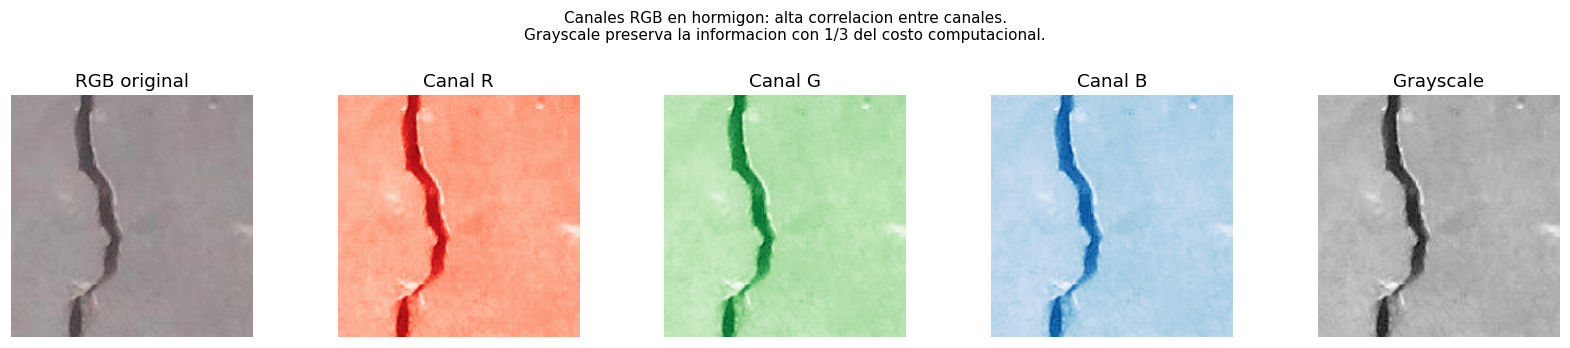

In [9]:
if len(img_paths) > 0:
    img_demo = cv2.imread(img_paths[0])
    img_rgb  = cv2.cvtColor(img_demo, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_demo, cv2.COLOR_BGR2GRAY)

    print('Varianza por canal:')
    for i, name in enumerate(['R', 'G', 'B']):
        print(f'  Canal {name}: {img_rgb[:,:,i].var():.1f}')
    print(f'  Grayscale:  {img_gray.var():.1f}')

    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    axes[0].imshow(img_rgb);                         axes[0].set_title('RGB original')
    axes[1].imshow(img_rgb[:,:,0], cmap='Reds_r');   axes[1].set_title('Canal R')
    axes[2].imshow(img_rgb[:,:,1], cmap='Greens_r'); axes[2].set_title('Canal G')
    axes[3].imshow(img_rgb[:,:,2], cmap='Blues_r');  axes[3].set_title('Canal B')
    axes[4].imshow(img_gray, cmap='gray');           axes[4].set_title('Grayscale')
    for ax in axes: ax.axis('off')
    plt.suptitle('Canales RGB en hormigon: alta correlacion entre canales.\n'
                 'Grayscale preserva la informacion con 1/3 del costo computacional.', fontsize=10, y=1.04)
    plt.tight_layout()
    guardar(fig, '03_rgb_vs_gray')
    plt.show()


In [10]:
def cargar_imagen(path, size=IMG_SIZE, grayscale=True):
    img = cv2.imread(path)
    if img is None: raise ValueError(f'No se pudo leer: {path}')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if grayscale else cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0
    if grayscale: img = np.expand_dims(img, axis=-1)
    return img

def cargar_mascara(path, size=IMG_SIZE):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if mask is None: mask = np.zeros((size, size), dtype=np.uint8)
    mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)
    return np.expand_dims((mask > 100).astype(np.float32), axis=-1)

print('Funciones de carga definidas.')


Funciones de carga definidas.



---



## 4. Division del dataset y pipeline tf.data

Division 70/15/15 para train/val/test. El pipeline tf.data carga los datos en batch sobre disco sin mantener todo el dataset en memoria, lo que es relevante dentro de los 12 GB de RAM disponibles en Colab.

El data augmentation para segmentacion tiene una restriccion critica: cualquier transformacion geometrica aplicada a la imagen debe aplicarse identicamente a la mascara. Los cambios de brillo y contraste se aplican solo a la imagen (la mascara es binaria, no tiene intensidad).


In [11]:
def construir_dataset(img_paths, mask_dir, size=IMG_SIZE, batch_size=BATCH_SIZE,
                       shuffle=True, augment=False, seed=SEED):
    img_list  = tf.constant(img_paths)
    stem_list = [Path(p).stem for p in img_paths]
    mask_list = tf.constant([str(Path(mask_dir) / (s + '.png')) for s in stem_list])

    def _load_pair(img_path, mask_path):
        img = tf.io.read_file(img_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.rgb_to_grayscale(img)
        img = tf.image.resize(img, [size, size], method='area')
        img = tf.cast(img, tf.float32) / 255.0
        mask_raw = tf.io.read_file(mask_path)
        mask = tf.image.decode_png(mask_raw, channels=1)
        mask = tf.image.resize(mask, [size, size], method='nearest')
        mask = tf.cast(mask > 100, tf.float32)
        return img, mask

    def _augment(img, mask):
        # Flip horizontal — sincronizado imagen y mascara
        if tf.random.uniform(()) > 0.5:
            img  = tf.image.flip_left_right(img)
            mask = tf.image.flip_left_right(mask)
        # Flip vertical
        if tf.random.uniform(()) > 0.5:
            img  = tf.image.flip_up_down(img)
            mask = tf.image.flip_up_down(mask)
        # Rotacion 90 grados (multiplos) — sincronizado
        k = tf.random.uniform((), 0, 4, dtype=tf.int32)
        img  = tf.image.rot90(img,  k=k)
        mask = tf.image.rot90(mask, k=k)
        # Brillo y contraste SOLO en imagen
        img = tf.image.random_brightness(img, max_delta=0.15)
        img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
        img = tf.clip_by_value(img, 0.0, 1.0)
        return img, mask

    ds = tf.data.Dataset.from_tensor_slices((img_list, mask_list))
    if shuffle: ds = ds.shuffle(buffer_size=len(img_paths), seed=seed)
    ds = ds.map(_load_pair, num_parallel_calls=tf.data.AUTOTUNE)
    if augment: ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

if len(img_paths) > 0:
    idx_all = list(range(len(img_paths)))
    idx_train, idx_test = train_test_split(idx_all, test_size=0.15, random_state=SEED)
    idx_train, idx_val  = train_test_split(idx_train, test_size=0.15, random_state=SEED)
    train_paths = [img_paths[i] for i in idx_train]
    val_paths   = [img_paths[i] for i in idx_val]
    test_paths  = [img_paths[i] for i in idx_test]
    ds_train = construir_dataset(train_paths, str(MASK_DIR), augment=True,  shuffle=True)
    ds_val   = construir_dataset(val_paths,   str(MASK_DIR), augment=False, shuffle=False)
    ds_test  = construir_dataset(test_paths,  str(MASK_DIR), augment=False, shuffle=False)
    print(f'Train: {len(train_paths)}  Val: {len(val_paths)}  Test: {len(test_paths)}')
    print(f'Batches por epoca (train): {len(ds_train)}')
else:
    print('Sin imagenes cargadas.')


Train: 295  Val: 53  Test: 62
Batches por epoca (train): 37



---



## 5. Metricas de evaluacion

El accuracy de pixeles resulta engañoso con desbalance de clases. Con 5-15% de pixeles de grieta, un modelo que predice uniformemente 'fondo' obtiene entre 85% y 95% de accuracy sin detectar ninguna grieta. Las metricas adecuadas para segmentacion binaria desbalanceada son:

- **IoU (Intersection over Union)**: TP / (TP + FP + FN). Penaliza tanto falsos positivos como falsos negativos. Estandar en segmentacion semantica. Valor minimo de referencia para produccion: IoU > 0.5.
- **Dice Coefficient**: 2TP / (2TP + FP + FN), equivalente al F1-score por pixel. Mas sensible que IoU a regiones pequeñas. Siempre Dice >= IoU.
- **Accuracy de pixeles**: se reporta como referencia para ilustrar su inadecuacion.


In [12]:
class DiceCoefficient(keras.metrics.Metric):
    def __init__(self, threshold=0.5, smooth=1e-6, name='dice', **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold; self.smooth = smooth
        self.dice_sum  = self.add_weight(name='dice_sum', initializer='zeros')
        self.count     = self.add_weight(name='count',    initializer='zeros')
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_bin   = tf.cast(y_pred > self.threshold, tf.float32)
        y_true       = tf.cast(y_true, tf.float32)
        intersection = tf.reduce_sum(y_true * y_pred_bin, axis=[1,2,3])
        denom        = tf.reduce_sum(y_true + y_pred_bin, axis=[1,2,3])
        dice         = tf.reduce_mean((2*intersection + self.smooth)/(denom + self.smooth))
        self.dice_sum.assign_add(dice); self.count.assign_add(1.0)
    def result(self): return self.dice_sum / (self.count + 1e-10)
    def reset_state(self): self.dice_sum.assign(0.0); self.count.assign(0.0)

class IoUMetric(keras.metrics.Metric):
    def __init__(self, threshold=0.5, smooth=1e-6, name='iou', **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold; self.smooth = smooth
        self.iou_sum   = self.add_weight(name='iou_sum', initializer='zeros')
        self.count     = self.add_weight(name='count',   initializer='zeros')
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_bin   = tf.cast(y_pred > self.threshold, tf.float32)
        y_true       = tf.cast(y_true, tf.float32)
        intersection = tf.reduce_sum(y_true * y_pred_bin, axis=[1,2,3])
        union        = tf.reduce_sum(y_true + y_pred_bin, axis=[1,2,3]) - intersection
        iou          = tf.reduce_mean((intersection + self.smooth)/(union + self.smooth))
        self.iou_sum.assign_add(iou); self.count.assign_add(1.0)
    def result(self): return self.iou_sum / (self.count + 1e-10)
    def reset_state(self): self.iou_sum.assign(0.0); self.count.assign(0.0)

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true       = tf.cast(y_true, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    denom        = tf.reduce_sum(y_true + y_pred,  axis=[1,2,3])
    return 1.0 - tf.reduce_mean((2*intersection + smooth) / (denom + smooth))

def bce_dice_loss(y_true, y_pred):
    bce = tf.reduce_mean(keras.losses.binary_crossentropy(y_true, y_pred))
    return 0.5 * bce + 0.5 * dice_loss(y_true, y_pred)

def focal_loss(y_true, y_pred, alpha=0.25, gamma=2.0):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0-1e-7)
    bce    = -y_true*tf.math.log(y_pred) - (1-y_true)*tf.math.log(1-y_pred)
    p_t    = y_true*y_pred + (1-y_true)*(1-y_pred)
    return tf.reduce_mean(alpha * tf.pow(1.0-p_t, gamma) * bce)

print('Metricas y funciones de perdida definidas.')


Metricas y funciones de perdida definidas.



---



## 6. Arquitectura U-Net

La U-Net (Ronneberger et al., 2015) fue diseñada para segmentacion de imagenes biomedicas con datasets pequeños. Su contribucion central son las **skip connections**, que conectan capas del encoder con capas del decoder del mismo nivel de resolucion.

**Encoder:** bloques de convolucion seguidos de maxpooling. Captura contexto semantico (donde hay grietas) pero pierde precision espacial.

**Cuello de botella:** representacion comprimida de mayor profundidad semantica.

**Decoder:** upsampling progresivo hacia la resolucion original.

**Skip connections:** concatenan feature maps del encoder con los del decoder al mismo nivel. Permiten al decoder recuperar la ubicacion exacta de bordes perdidos durante el downsampling. Para grietas de 1-3 pixeles de ancho, esta informacion es critica.


In [13]:
def bloque_conv(x, filters, kernel_size=3, use_bn=True, dropout=0.0,
                n_convs=2, name_prefix=''):
    for k in range(n_convs):
        x = layers.Conv2D(filters, kernel_size, padding='same',
                          kernel_initializer='he_normal',
                          name=f'{name_prefix}_c{k}')(x)
        if use_bn:
            x = layers.BatchNormalization(name=f'{name_prefix}_bn{k}')(x)
        x = layers.Activation('relu', name=f'{name_prefix}_r{k}')(x)
    if dropout > 0:
        x = layers.SpatialDropout2D(dropout, name=f'{name_prefix}_drop')(x)
    return x

def unet(input_shape=(IMG_SIZE, IMG_SIZE, N_CHANNELS),
         filters_base=32, depth=4, use_bn=True, dropout=0.1,
         use_skip=True, n_convs_per_block=2, nombre='unet'):
    inputs = keras.Input(shape=input_shape, name='input')
    x, skips = inputs, []
    # ENCODER
    for lvl in range(depth):
        f = filters_base * (2 ** lvl)
        x = bloque_conv(x, f, use_bn=use_bn, dropout=dropout,
                        n_convs=n_convs_per_block, name_prefix=f'enc{lvl}')
        skips.append(x)
        x = layers.MaxPooling2D(2, name=f'pool{lvl}')(x)
    # CUELLO DE BOTELLA
    f_bot = filters_base * (2 ** depth)
    x     = bloque_conv(x, f_bot, use_bn=use_bn, dropout=dropout,
                        n_convs=n_convs_per_block, name_prefix='bot')
    # DECODER
    for lvl in reversed(range(depth)):
        f = filters_base * (2 ** lvl)
        x = layers.Conv2DTranspose(f, 2, strides=2, padding='same', name=f'up{lvl}')(x)
        if use_skip:
            x = layers.Concatenate(name=f'skip{lvl}')([x, skips[lvl]])
        x = bloque_conv(x, f, use_bn=use_bn, dropout=dropout,
                        n_convs=n_convs_per_block, name_prefix=f'dec{lvl}')
    # SALIDA
    outputs = layers.Conv2D(1, 1, activation='sigmoid', name='output')(x)
    return keras.Model(inputs, outputs, name=nombre)

m_test = unet(filters_base=16, depth=4, nombre='test')
print(f'U-Net (16 base, depth=4): {m_test.count_params():,} parametros')
del m_test


U-Net (16 base, depth=4): 1,946,705 parametros



---



## 7. Experimento: skip connections vs. encoder-decoder puro

Se comparan empiricamente dos variantes: U-Net con skip connections y el mismo encoder-decoder sin ellas. La hipotesis es que sin skip connections el decoder no puede recuperar la ubicacion exacta de grietas delgadas porque esa informacion se disipa durante el downsampling y no hay camino para recuperarla desde el cuello de botella.


In [14]:
def compilar_y_entrenar(modelo, ds_train, ds_val, epochs=50,
                         loss_fn=None, lr=1e-3, nombre=''):
    if loss_fn is None: loss_fn = bce_dice_loss
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=loss_fn,
        metrics=[keras.metrics.BinaryAccuracy(name='acc'),
                 DiceCoefficient(name='dice'),
                 IoUMetric(name='iou')]
    )
    cb = [
        EarlyStopping(monitor='val_iou', patience=10, mode='max',
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_iou', factor=0.5, patience=5,
                          mode='max', min_lr=1e-6, verbose=0),
        ModelCheckpoint(f'{nombre}_best.weights.h5', monitor='val_iou',
                        mode='max', save_best_only=True,
                        save_weights_only=True, verbose=0),
    ]
    t0   = time.time()
    hist = modelo.fit(ds_train, validation_data=ds_val,
                       epochs=epochs, callbacks=cb, verbose=1)
    return hist, time.time() - t0

if len(img_paths) > 0:
    modelo_skip   = unet(filters_base=16, depth=4, use_skip=True,  nombre='skip')
    modelo_nosk   = unet(filters_base=16, depth=4, use_skip=False, nombre='nosk')
    print(f'Con skip:   {modelo_skip.count_params():,} parametros')
    print(f'Sin skip:   {modelo_nosk.count_params():,} parametros')
    print()
    tf.random.set_seed(SEED)
    hist_skip, t_sk = compilar_y_entrenar(modelo_skip, ds_train, ds_val, epochs=60, nombre='sk')
    tf.random.set_seed(SEED)
    hist_nosk, t_ns = compilar_y_entrenar(modelo_nosk, ds_train, ds_val, epochs=60, nombre='ns')
    print(f'Con skip:  val_IoU={max(hist_skip.history["val_iou"]):.4f}  ({t_sk:.0f}s)')
    print(f'Sin skip:  val_IoU={max(hist_nosk.history["val_iou"]):.4f}  ({t_ns:.0f}s)')


Con skip:   1,946,705 parametros
Sin skip:   1,750,865 parametros

Epoch 1/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - acc: 0.8853 - dice: 0.6447 - iou: 0.5142 - loss: 0.5586 - val_acc: 0.1665 - val_dice: 0.1811 - val_iou: 0.1024 - val_loss: 3.6479 - learning_rate: 0.0010
Epoch 2/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - acc: 0.9561 - dice: 0.7901 - iou: 0.6711 - loss: 0.4328 - val_acc: 0.9440 - val_dice: 0.5361 - val_iou: 0.4099 - val_loss: 0.5131 - learning_rate: 0.0010
Epoch 3/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - acc: 0.9638 - dice: 0.8200 - iou: 0.7069 - loss: 0.3756 - val_acc: 0.2669 - val_dice: 0.2038 - val_iou: 0.1182 - val_loss: 3.9938 - learning_rate: 0.0010
Epoch 4/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - acc: 0.9673 - dice: 0.8326 - iou: 0.7246 - loss: 0.3298 - val_acc: 0.9298 - val_dice: 0.6793 - val_iou: 0.5326 - val_loss: 0.4638 - learning_rate: 0.0010
Epoch 5/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - acc: 0.9655 - dice: 0.8329 - iou: 0.7276 - loss: 0.29

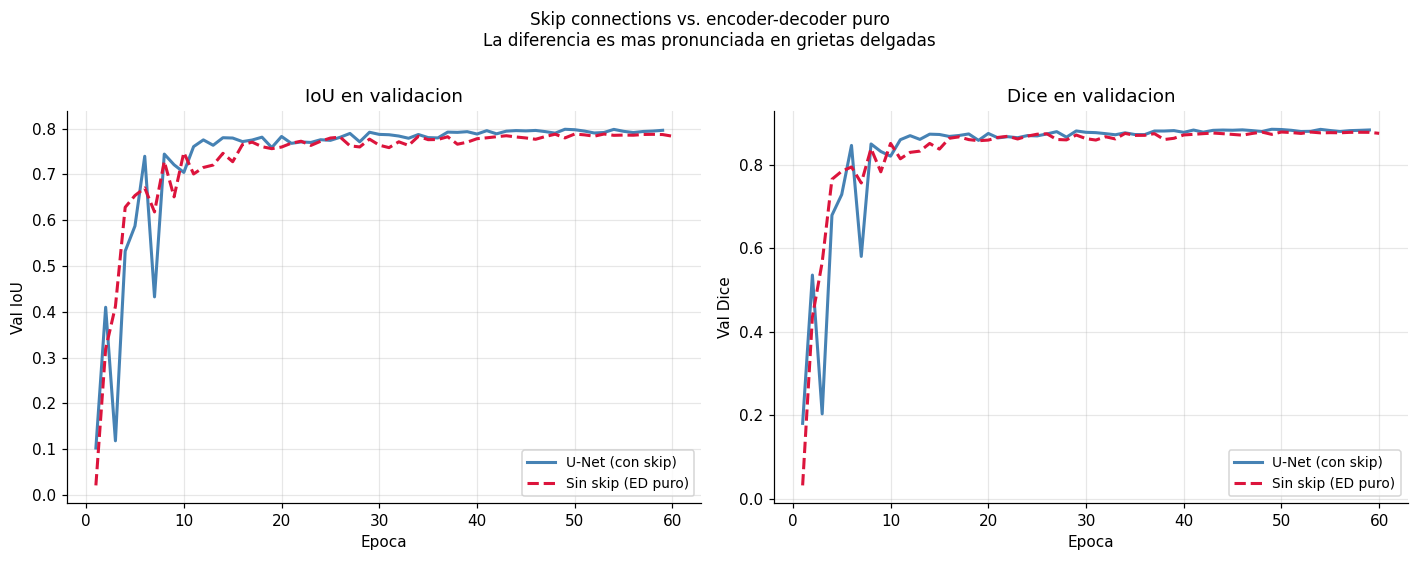

In [15]:
if len(img_paths) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for hist, label, color, ls in [
        (hist_skip.history, 'U-Net (con skip)', 'steelblue', '-'),
        (hist_nosk.history, 'Sin skip (ED puro)', 'crimson', '--'),
    ]:
        ep = range(1, len(hist['val_iou']) + 1)
        axes[0].plot(ep, hist['val_iou'],  color=color, ls=ls, lw=2, label=label)
        axes[1].plot(ep, hist['val_dice'], color=color, ls=ls, lw=2, label=label)
    for ax, yl, tl in [
        (axes[0], 'Val IoU',  'IoU en validacion'),
        (axes[1], 'Val Dice', 'Dice en validacion'),
    ]:
        ax.set_xlabel('Epoca'); ax.set_ylabel(yl)
        ax.set_title(tl); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.suptitle('Skip connections vs. encoder-decoder puro\n'
                 'La diferencia es mas pronunciada en grietas delgadas', fontsize=11, y=1.01)
    plt.tight_layout()
    guardar(fig, '04_skip_vs_nosk')
    plt.show()



---



## 8. Experimento: capacidad de la red

Con un dataset pequeño (~500 imagenes), la capacidad del modelo es un factor critico. Una red con demasiados parametros puede memorizar el conjunto de entrenamiento sin aprender la estructura general de las grietas. Una red con muy pocos parametros puede carecer de expresividad para segmentar estructuras finas.

Se comparan tres configuraciones: Tiny, Small y Medium. La hipotesis es que Medium ofrece el balance optimo entre capacidad y regularizacion implicita del dataset pequeño.


In [16]:
configs = {
    'Tiny  (4b, d=3)':  {'filters_base': 4,  'depth': 3},
    'Small (8b, d=4)':  {'filters_base': 8,  'depth': 4},
    'Medium(16b,d=4)':  {'filters_base': 16, 'depth': 4},
}

print(f"  {'Config':<20}  {'Params':>10}")
print('  ' + '-'*32)
for nombre, cfg in configs.items():
    m = unet(filters_base=cfg['filters_base'], depth=cfg['depth'], nombre='tmp')
    print(f"  {nombre:<20}  {m.count_params():>10,}")
    del m


  Config                    Params
  --------------------------------
  Tiny  (4b, d=3)           30,997
  Small (8b, d=4)          488,617
  Medium(16b,d=4)        1,946,705


In [17]:
resultados_tam = {}

if len(img_paths) > 0:
    for nombre_cfg, cfg in configs.items():
        print(f'\nEntrenando {nombre_cfg}...')
        tf.random.set_seed(SEED)
        m = unet(filters_base=cfg['filters_base'], depth=cfg['depth'],
                 use_bn=True, dropout=0.1, use_skip=True,
                 nombre=re.sub(r'[^A-Za-z0-9_.\-]', '_', nombre_cfg[:12]))
        hist, elapsed = compilar_y_entrenar(
            m, ds_train, ds_val, epochs=60,
            nombre=re.sub(r'[^A-Za-z0-9_.\-]', '_', nombre_cfg[:12]))
        resultados_tam[nombre_cfg] = {
            'iou': max(hist.history['val_iou']),
            'dice': max(hist.history['val_dice']),
            'params': m.count_params(),
            'tiempo': elapsed,
            'history': hist.history,
        }
        print(f"  IoU={resultados_tam[nombre_cfg]['iou']:.4f}  "
              f"Dice={resultados_tam[nombre_cfg]['dice']:.4f}  "
              f"Params={m.count_params():,}  t={elapsed:.0f}s")

    print('\n' + '='*60)
    print('TABLA — Comparacion de capacidad de red')
    print('='*60)
    print(f"  {'Config':<22}  {'Params':>10}  {'IoU':>8}  {'Dice':>8}  {'t(s)':>6}")
    print('  ' + '-'*58)
    for n, r in resultados_tam.items():
        print(f"  {n:<22}  {r['params']:>10,}  {r['iou']:>8.4f}  {r['dice']:>8.4f}  {r['tiempo']:>6.0f}")



Entrenando Tiny  (4b, d=3)...
Epoch 1/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 40s 452ms/step - acc: 0.7655 - dice: 0.1339 - iou: 0.0781 - loss: 0.7190 - val_acc: 0.9003 - val_dice: 0.0347 - val_iou: 0.0180 - val_loss: 0.5997 - learning_rate: 0.0010
Epoch 2/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - acc: 0.8668 - dice: 0.4260 - iou: 0.3043 - loss: 0.6136 - val_acc: 0.9008 - val_dice: 0.0072 - val_iou: 0.0037 - val_loss: 0.5928 - learning_rate: 0.0010
Epoch 3/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - acc: 0.9021 - dice: 0.5864 - iou: 0.4491 - loss: 0.5340 - val_acc: 0.8982 - val_dice: 0.0102 - val_iou: 0.0053 - val_loss: 0.5713 - learning_rate: 0.0010
Epoch 4/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - acc: 0.9176 - dice: 0.6445 - iou: 0.5074 - loss: 0.4710 - val_acc: 0.9219 - val_dice: 0.3899 - val_iou: 0.2702 - val_loss: 0.4618 - learning_rate: 0.0010
Epoch 5/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - acc: 0.9446 - dice: 0.7422 - iou: 0.6137 - loss: 0.4187 - val_acc: 0.9594 - val_dice: 

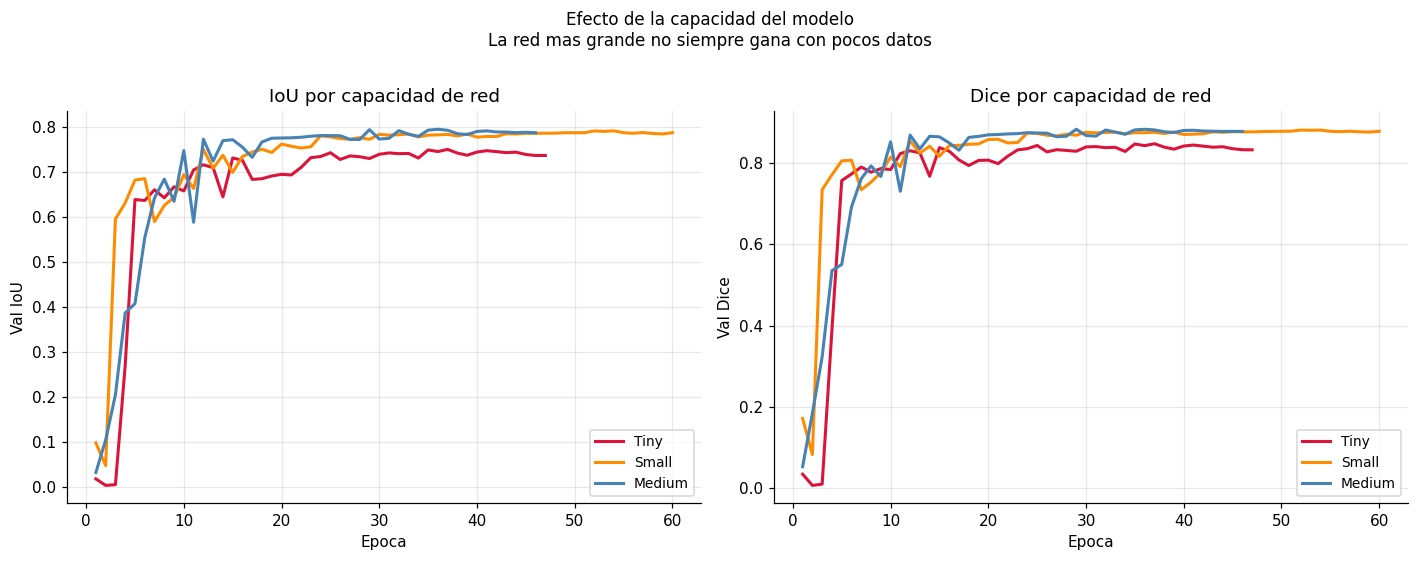

In [18]:
if resultados_tam:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    colores = ['crimson', 'darkorange', 'steelblue']
    for (nombre_cfg, r), color in zip(resultados_tam.items(), colores):
        ep    = range(1, len(r['history']['val_iou']) + 1)
        label = nombre_cfg.split('(')[0].strip()
        axes[0].plot(ep, r['history']['val_iou'],  color=color, lw=2, label=label)
        axes[1].plot(ep, r['history']['val_dice'], color=color, lw=2, label=label)
    for ax, yl, tl in [
        (axes[0], 'Val IoU',  'IoU por capacidad de red'),
        (axes[1], 'Val Dice', 'Dice por capacidad de red'),
    ]:
        ax.set_xlabel('Epoca'); ax.set_ylabel(yl)
        ax.set_title(tl); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.suptitle('Efecto de la capacidad del modelo\n'
                 'La red mas grande no siempre gana con pocos datos', fontsize=11, y=1.01)
    plt.tight_layout()
    guardar(fig, '05_capacidad_red')
    plt.show()


SELECCION DE CAPACIDAD - evaluacion en grietas filiformes (VALIDACION)
  Imagenes de validacion: 53
  Corte del tercil inferior de % de grieta: 6.62%
  Subconjunto filiforme:  18 imagenes (% grieta medio 4.77%, resto 12.38%)

  Config                   Params   IoU val  IoU filif.    delta
  --------------------------------------------------------------
  Tiny  (4b, d=3)          30,997    0.7481      0.6655  -0.0825
  Small (8b, d=4)         488,617    0.7903      0.7364  -0.0540
  Medium(16b,d=4)       1,946,705    0.7941      0.7379  -0.0562

  IoU en filiformes  Small=0.7364   Medium=0.7379   ventaja de Medium = +0.0016
  Umbral de decision: ventaja >= 0.02 IoU absoluto para justificar 4.0x parametros.
  => DECISION: SMALL. La capacidad extra NO aporta ventaja clara en grietas filiformes (+0.0016 < 0.02); con 295 imagenes de train se prefiere el modelo de 488,617 parametros.

  CONFIGURACION FINAL: Small (8b, d=4)  (filters_base=8, depth=4)


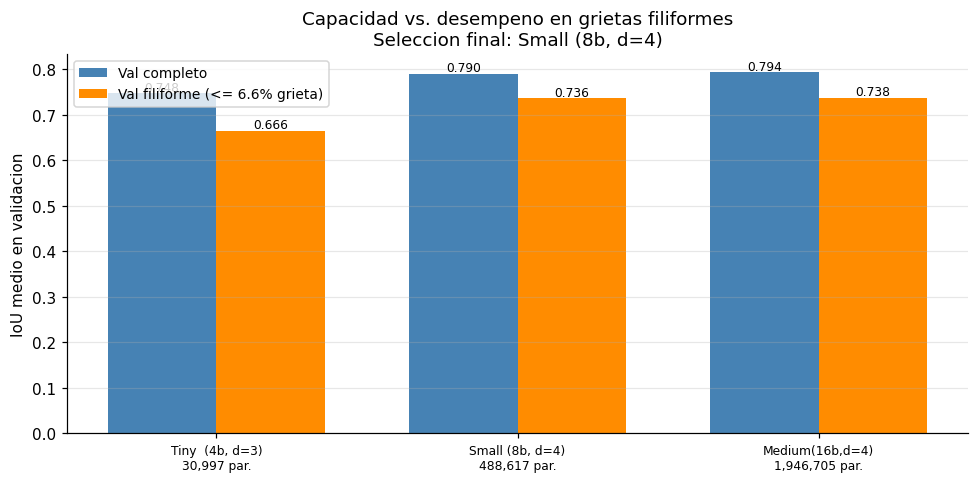

In [19]:
# ====== (f) DECISION DE CAPACIDAD SOBRE EVIDENCIA: grietas filiformes ======
# El argumento del informe ("la red mas grande no siempre gana con 295 imagenes de train")
# contradice la eleccion de Medium (1,95 M params). Aqui se mide el UNICO escenario donde
# la capacidad extra podria justificarse: el subconjunto de VALIDACION con menor % de grieta
# (grietas filiformes / delgadas), que es donde el detalle espacial importa.
# DECISION POR DEFECTO: Small. Solo se elige Medium si supera a Small en filiformes
# por un margen absoluto >= DELTA_FILIFORME.

DELTA_FILIFORME  = 0.02    # 2 puntos de IoU absolutos: margen minimo para justificar 4x params
PCT_FILIFORME    = 0.33    # tercil inferior de % de grieta en validacion

def _iou_dice_en_paths(modelo, paths, umbral=0.5):
    """IoU y Dice medios por imagen sobre una lista de rutas (sin augmentation)."""
    ds = construir_dataset(paths, str(MASK_DIR), augment=False, shuffle=False)
    ious, dices = [], []
    for bi, bm in ds:
        pr = modelo.predict(bi, verbose=0)
        pb = (pr > umbral).astype(np.float32)
        for i in range(len(bi)):
            mt = bm[i].numpy().flatten().astype(int)
            mp = pb[i].flatten().astype(int)
            inter = (mt & mp).sum(); union = (mt | mp).sum()
            ious.append(inter/union if union > 0 else 1.0)
            dices.append(2*inter/(mt.sum()+mp.sum()+1e-6))
    return float(np.mean(ious)), float(np.mean(dices)), np.array(ious)

if len(img_paths) > 0 and resultados_tam:
    # --- 1) Fraccion de grieta real de cada imagen de VALIDACION ---
    frac_val = []
    for p in val_paths:
        mp_ = MASK_DIR / (Path(p).stem + '.png')
        m   = cv2.imread(str(mp_), cv2.IMREAD_GRAYSCALE)
        frac_val.append(float((m > 100).mean()) if m is not None else 0.0)
    frac_val = np.array(frac_val)
    corte    = np.quantile(frac_val, PCT_FILIFORME)
    idx_fil  = np.where(frac_val <= corte)[0]
    paths_fil = [val_paths[i] for i in idx_fil]

    print('='*70)
    print('SELECCION DE CAPACIDAD - evaluacion en grietas filiformes (VALIDACION)')
    print('='*70)
    print(f'  Imagenes de validacion: {len(val_paths)}')
    print(f'  Corte del tercil inferior de % de grieta: {corte*100:.2f}%')
    print(f'  Subconjunto filiforme:  {len(paths_fil)} imagenes '
          f'(% grieta medio {frac_val[idx_fil].mean()*100:.2f}%, '
          f'resto {frac_val[frac_val>corte].mean()*100:.2f}%)')
    print()

    # --- 2) Reconstruir cada modelo y cargar los pesos ya entrenados ---
    # compilar_y_entrenar guardo f'{nombre}_best.weights.h5' con nombre sanitizado:
    #   'Tiny___4b__d', 'Small__8b__d', 'Medium_16b_d'
    resultados_filiforme = {}
    for nombre_cfg, cfg in configs.items():
        base = re.sub(r'[^A-Za-z0-9_.\-]', '_', nombre_cfg[:12])
        ckpt = f'{base}_best.weights.h5'
        if not os.path.exists(ckpt):
            print(f'  [SALTEADO] {nombre_cfg}: no se encontro {ckpt}')
            continue
        m = unet(filters_base=cfg['filters_base'], depth=cfg['depth'],
                 use_bn=True, dropout=0.1, use_skip=True, nombre=base + '_eval')
        m.load_weights(ckpt)
        iou_all, dice_all, _ = _iou_dice_en_paths(m, val_paths)
        iou_fil, dice_fil, _ = _iou_dice_en_paths(m, paths_fil)
        resultados_filiforme[nombre_cfg] = {
            'params':   m.count_params(),
            'iou_val':  iou_all,  'dice_val':  dice_all,
            'iou_fil':  iou_fil,  'dice_fil':  dice_fil,
        }
        k = nombre_cfg.split('(')[0].strip().lower()
        reg(f'capacidad_{k}_iou_val_completo',  iou_all)
        reg(f'capacidad_{k}_iou_val_filiforme', iou_fil)
        reg(f'capacidad_{k}_params',            int(m.count_params()))
        del m

    print(f"  {'Config':<20} {'Params':>10} {'IoU val':>9} {'IoU filif.':>11} {'delta':>8}")
    print('  ' + '-'*62)
    for n, r in resultados_filiforme.items():
        print(f"  {n:<20} {r['params']:>10,} {r['iou_val']:>9.4f} "
              f"{r['iou_fil']:>11.4f} {r['iou_fil']-r['iou_val']:>+8.4f}")

    # --- 3) Regla de decision explicita ---
    K_SMALL, K_MEDIUM = 'Small (8b, d=4)', 'Medium(16b,d=4)'
    FB_FINAL, DEPTH_FINAL, CFG_FINAL = 8, 4, K_SMALL      # DEFECTO: Small
    if K_SMALL in resultados_filiforme and K_MEDIUM in resultados_filiforme:
        iou_s = resultados_filiforme[K_SMALL]['iou_fil']
        iou_m = resultados_filiforme[K_MEDIUM]['iou_fil']
        ventaja = iou_m - iou_s
        print()
        print(f'  IoU en filiformes  Small={iou_s:.4f}   Medium={iou_m:.4f}   '
              f'ventaja de Medium = {ventaja:+.4f}')
        print(f'  Umbral de decision: ventaja >= {DELTA_FILIFORME:.2f} IoU absoluto '
              f'para justificar {resultados_filiforme[K_MEDIUM]["params"]/resultados_filiforme[K_SMALL]["params"]:.1f}x parametros.')
        if ventaja >= DELTA_FILIFORME:
            FB_FINAL, DEPTH_FINAL, CFG_FINAL = 16, 4, K_MEDIUM
            print(f'  => DECISION: MEDIUM. La capacidad extra SI aporta en grietas '
                  f'filiformes ({ventaja:+.4f} >= {DELTA_FILIFORME:.2f}).')
        else:
            print(f'  => DECISION: SMALL. La capacidad extra NO aporta ventaja clara en '
                  f'grietas filiformes ({ventaja:+.4f} < {DELTA_FILIFORME:.2f}); '
                  f'con 295 imagenes de train se prefiere el modelo de '
                  f'{resultados_filiforme[K_SMALL]["params"]:,} parametros.')
        reg('capacidad_ventaja_medium_filiforme', ventaja)
        reg('capacidad_delta_decision',           DELTA_FILIFORME, dec=2)
    else:
        print('  AVISO: faltan checkpoints de Small y/o Medium. Se mantiene el DEFECTO: Small.')

    reg('capacidad_seleccionada',        CFG_FINAL)
    reg('capacidad_filters_base_final',  int(FB_FINAL))
    reg('capacidad_depth_final',         int(DEPTH_FINAL))
    reg('capacidad_n_val_filiformes',    int(len(paths_fil)))
    reg('capacidad_corte_filiforme_pct', corte*100)
    print(f'\n  CONFIGURACION FINAL: {CFG_FINAL}  '
          f'(filters_base={FB_FINAL}, depth={DEPTH_FINAL})')

    # --- 4) Figura ---
    if resultados_filiforme:
        fig, ax = plt.subplots(figsize=(9, 4.5))
        nombres = list(resultados_filiforme.keys())
        x = np.arange(len(nombres)); w = 0.36
        ax.bar(x - w/2, [resultados_filiforme[n]['iou_val'] for n in nombres], w,
               label='Val completo', color='steelblue')
        ax.bar(x + w/2, [resultados_filiforme[n]['iou_fil'] for n in nombres], w,
               label=f'Val filiforme (<= {corte*100:.1f}% grieta)', color='darkorange')
        for i, n in enumerate(nombres):
            ax.text(i - w/2, resultados_filiforme[n]['iou_val'] + .005,
                    f"{resultados_filiforme[n]['iou_val']:.3f}", ha='center', fontsize=8)
            ax.text(i + w/2, resultados_filiforme[n]['iou_fil'] + .005,
                    f"{resultados_filiforme[n]['iou_fil']:.3f}", ha='center', fontsize=8)
        ax.set_xticks(x); ax.set_xticklabels(
            [f"{n}\n{resultados_filiforme[n]['params']:,} par." for n in nombres], fontsize=8)
        ax.set_ylabel('IoU medio en validacion')
        ax.set_title('Capacidad vs. desempeno en grietas filiformes\n'
                     f'Seleccion final: {CFG_FINAL}')
        ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        guardar(fig, '05b_capacidad_filiformes')
        plt.show()
else:
    FB_FINAL, DEPTH_FINAL, CFG_FINAL = 8, 4, 'Small (8b, d=4)'
    print('Sin datos: se usa la configuracion por defecto Small (8b, d=4).')



---



## 9. Experimento: funcion de perdida

Con 5-15% de pixeles de grieta, Binary Cross-Entropy pura resulta inadecuada: el modelo puede minimizar la BCE prediciendo uniformemente 'fondo', porque el 85-95% de los pixeles son superficie sana. Esto produce IoU y Dice cercanos a cero aunque la BCE sea baja.

Se comparan cuatro funciones de perdida con la misma arquitectura:
- **BCE pura**: baseline para ilustrar el problema.
- **Dice Loss**: optimiza directamente la metrica de evaluacion.
- **BCE + Dice**: combinacion mas usada en segmentacion medica. BCE aporta gradientes estables al inicio; Dice refina la deteccion de bordes.
- **Focal Loss**: penaliza dinamicamente los pixeles dificiles de clasificar.


In [20]:
if len(img_paths) > 0:
    resultados_loss = {}
    losses_probar = {
        'BCE_pura':   keras.losses.binary_crossentropy,
        'Dice_Loss':  dice_loss,
        'BCE+Dice':   bce_dice_loss,
        'Focal_Loss': focal_loss,
    }
    for nombre_loss, loss_fn in losses_probar.items():
        print(f'  Entrenando con {nombre_loss}...')
        tf.random.set_seed(SEED)
        m = unet(filters_base=8, depth=4, use_bn=True, dropout=0.1,
                 nombre='loss_' + re.sub(r'[^A-Za-z0-9_.\-]', '_', nombre_loss[:8]))
        hist, _ = compilar_y_entrenar(
            m, ds_train, ds_val, epochs=50,
            loss_fn=loss_fn, nombre='loss_' + re.sub(r'[^A-Za-z0-9_.\-]', '_', nombre_loss[:8]))
        resultados_loss[nombre_loss] = {
            'iou':  max(hist.history['val_iou']),
            'dice': max(hist.history['val_dice']),
            'history': hist.history,
        }
        print(f"    IoU={resultados_loss[nombre_loss]['iou']:.4f}  "
              f"Dice={resultados_loss[nombre_loss]['dice']:.4f}")

    print('\n' + '='*40)
    print('TABLA — Funcion de perdida')
    print('='*40)
    print(f"  {'Loss':<15}  {'IoU':>8}  {'Dice':>8}")
    print('  ' + '-'*35)
    for n, r in resultados_loss.items():
        print(f"  {n:<15}  {r['iou']:>8.4f}  {r['dice']:>8.4f}")


  Entrenando con BCE_pura...
Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 45s 502ms/step - acc: 0.8169 - dice: 0.5619 - iou: 0.4251 - loss: 0.6413 - val_acc: 0.5248 - val_dice: 0.0242 - val_iou: 0.0127 - val_loss: 0.7112 - learning_rate: 0.0010
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - acc: 0.9312 - dice: 0.6792 - iou: 0.5413 - loss: 0.5382 - val_acc: 0.9064 - val_dice: 0.0805 - val_iou: 0.0523 - val_loss: 0.5627 - learning_rate: 0.0010
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - acc: 0.9518 - dice: 0.7354 - iou: 0.6126 - loss: 0.4806 - val_acc: 0.9305 - val_dice: 0.4148 - val_iou: 0.3013 - val_loss: 0.4714 - learning_rate: 0.0010
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - acc: 0.9569 - dice: 0.7656 - iou: 0.6448 - loss: 0.4421 - val_acc: 0.9468 - val_dice: 0.6370 - val_iou: 0.5007 - val_loss: 0.4016 - learning_rate: 0.0010
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - acc: 0.9656 - dice: 0.7950 - iou: 0.6808 - loss: 0.4005 - val_acc: 0.9508 - val_dice: 0.

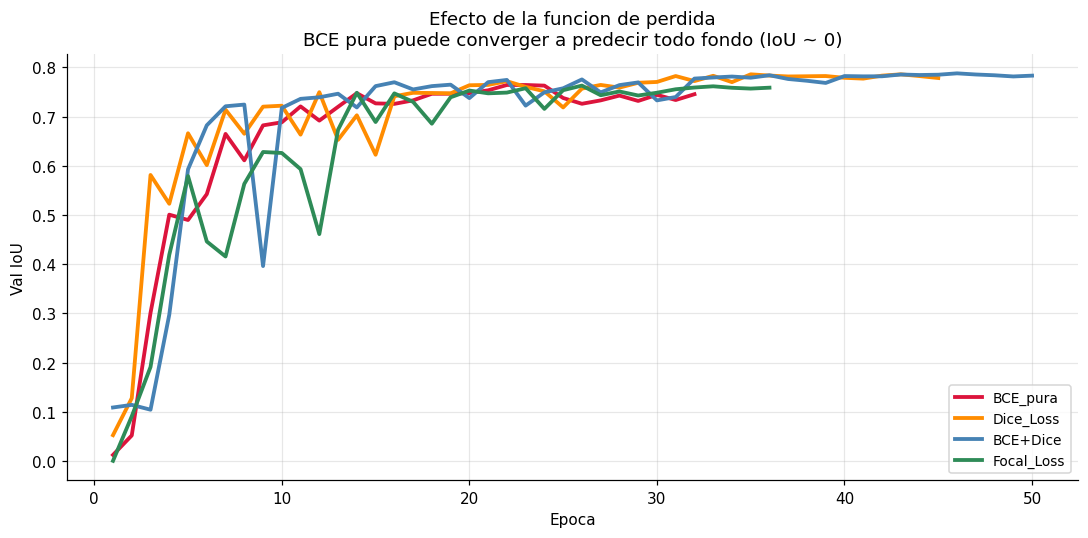

In [21]:
if resultados_loss:
    fig, ax = plt.subplots(figsize=(10, 5))
    colores = ['crimson', 'darkorange', 'steelblue', 'seagreen']
    for (nombre, r), c in zip(resultados_loss.items(), colores):
        ep = range(1, len(r['history']['val_iou']) + 1)
        ax.plot(ep, r['history']['val_iou'], color=c, lw=2.5, label=nombre)
    ax.set_xlabel('Epoca'); ax.set_ylabel('Val IoU')
    ax.set_title('Efecto de la funcion de perdida\n'
                 'BCE pura puede converger a predecir todo fondo (IoU ~ 0)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    guardar(fig, '06_loss_comparison')
    plt.show()


In [22]:
# ============ (e) TABLAS RESUMEN DE LOS TRES EXPERIMENTOS ============
# Respaldo impreso de las tablas del informe: max(val_iou), max(val_dice),
# epoca del maximo y parametros. Antes ninguna de las tres estaba impresa completa.

def _resumen_hist(h):
    vi = np.array(h['val_iou']); vd = np.array(h['val_dice'])
    return {
        'max_val_iou':   float(vi.max()),
        'ep_max_iou':    int(vi.argmax() + 1),
        'max_val_dice':  float(vd.max()),
        'ep_max_dice':   int(vd.argmax() + 1),
        'epocas_corridas': int(len(vi)),
    }

def _imprimir_tabla(titulo, filas, cols):
    print('\n' + '='*88)
    print(titulo)
    print('='*88)
    anchos = {c: max(len(c), max((len(str(f[c])) for f in filas), default=0)) + 2 for c in cols}
    print(''.join(f'{c:<{anchos[c]}}' for c in cols))
    print('-'*sum(anchos.values()))
    for f in filas:
        print(''.join(f'{str(f[c]):<{anchos[c]}}' for c in cols))

# ---------- TABLA A: skip connections ----------
if 'hist_skip' in dir() and 'hist_nosk' in dir():
    filas_skip = []
    for etiqueta, h, modelo, seg in [
        ('U-Net con skip',        hist_skip.history, modelo_skip, t_sk),
        ('Encoder-decoder puro',  hist_nosk.history, modelo_nosk, t_ns),
    ]:
        r = _resumen_hist(h)
        filas_skip.append({
            'Configuracion': etiqueta,
            'Params': f"{modelo.count_params():,}",
            'max val_IoU': f"{r['max_val_iou']:.4f}",
            'ep.': r['ep_max_iou'],
            'max val_Dice': f"{r['max_val_dice']:.4f}",
            'ep. ': r['ep_max_dice'],
            'Epocas': r['epocas_corridas'],
            't(s)': f'{seg:.0f}',
        })
        clave = 'skip' if 'con skip' in etiqueta else 'noskip'
        reg(f'exp_skip_{clave}_max_val_iou',  r['max_val_iou'])
        reg(f'exp_skip_{clave}_max_val_dice', r['max_val_dice'])
        reg(f'exp_skip_{clave}_epoca_max_iou', r['ep_max_iou'])
        reg(f'exp_skip_{clave}_params',        int(modelo.count_params()))
        reg(f'exp_skip_{clave}_tiempo_s',      seg, dec=1)
    _imprimir_tabla('TABLA A - Skip connections vs. encoder-decoder puro', filas_skip,
                    ['Configuracion','Params','max val_IoU','ep.','max val_Dice','ep. ',
                     'Epocas','t(s)'])
    d_iou = (max(hist_skip.history['val_iou']) - max(hist_nosk.history['val_iou']))
    print(f'\n  Delta max val_IoU (skip - sin skip): {d_iou:+.4f}  ({d_iou*100:+.2f} pp)')
    reg('exp_skip_delta_val_iou', d_iou)
else:
    print('TABLA A NO DISPONIBLE: falta hist_skip / hist_nosk.')

# ---------- TABLA B: capacidad ----------
if 'resultados_tam' in dir() and resultados_tam:
    filas_cap = []
    for nombre_cfg, r in resultados_tam.items():
        rr = _resumen_hist(r['history'])
        filas_cap.append({
            'Configuracion': nombre_cfg,
            'Params': f"{r['params']:,}",
            'max val_IoU': f"{rr['max_val_iou']:.4f}",
            'ep.': rr['ep_max_iou'],
            'max val_Dice': f"{rr['max_val_dice']:.4f}",
            'ep. ': rr['ep_max_dice'],
            'Epocas': rr['epocas_corridas'],
            't(s)': f"{r['tiempo']:.0f}",
        })
        k = nombre_cfg.split('(')[0].strip().lower()
        reg(f'exp_capacidad_{k}_max_val_iou',   rr['max_val_iou'])
        reg(f'exp_capacidad_{k}_max_val_dice',  rr['max_val_dice'])
        reg(f'exp_capacidad_{k}_epoca_max_iou', rr['ep_max_iou'])
        reg(f'exp_capacidad_{k}_params',        int(r['params']))
        reg(f'exp_capacidad_{k}_tiempo_s',      r['tiempo'], dec=1)
    _imprimir_tabla('TABLA B - Capacidad de la red', filas_cap,
                    ['Configuracion','Params','max val_IoU','ep.','max val_Dice','ep. ',
                     'Epocas','t(s)'])
else:
    print('TABLA B NO DISPONIBLE: falta resultados_tam.')

# ---------- TABLA C: funcion de perdida ----------
if 'resultados_loss' in dir() and resultados_loss:
    _params_loss = unet(filters_base=8, depth=4, nombre='tmp_params').count_params()
    filas_loss = []
    for nombre_loss, r in resultados_loss.items():
        rr = _resumen_hist(r['history'])
        filas_loss.append({
            'Perdida': nombre_loss,
            'Params': f'{_params_loss:,}',
            'max val_IoU': f"{rr['max_val_iou']:.4f}",
            'ep.': rr['ep_max_iou'],
            'max val_Dice': f"{rr['max_val_dice']:.4f}",
            'ep. ': rr['ep_max_dice'],
            'Epocas': rr['epocas_corridas'],
        })
        k = nombre_loss.lower().replace('+','_')
        reg(f'exp_loss_{k}_max_val_iou',   rr['max_val_iou'])
        reg(f'exp_loss_{k}_max_val_dice',  rr['max_val_dice'])
        reg(f'exp_loss_{k}_epoca_max_iou', rr['ep_max_iou'])
    _imprimir_tabla('TABLA C - Funcion de perdida (todas con U-Net 8b, d=4)', filas_loss,
                    ['Perdida','Params','max val_IoU','ep.','max val_Dice','ep. ','Epocas'])
    reg('exp_loss_params_arquitectura', int(_params_loss))
    print('\n  NOTA: las cuatro perdidas se entrenaron con la MISMA arquitectura '
          f'(filters_base=8, depth=4, {_params_loss:,} parametros), por lo que la '
          'comparacion aisla el efecto de la perdida.')
else:
    print('TABLA C NO DISPONIBLE: falta resultados_loss.')

print(f'\n  Particiones: train={len(train_paths)}  val={len(val_paths)}  test={len(test_paths)}'
      f'  (total {len(img_paths)})')



TABLA A - Skip connections vs. encoder-decoder puro
Configuracion         Params     max val_IoU  ep.  max val_Dice  ep.   Epocas  t(s)  
-------------------------------------------------------------------------------------
U-Net con skip        1,946,705  0.7987       49   0.8851        49    59      307   
Encoder-decoder puro  1,750,865  0.7883       53   0.8785        50    60      255   

  Delta max val_IoU (skip - sin skip): +0.0104  (+1.04 pp)

TABLA B - Capacidad de la red
Configuracion    Params     max val_IoU  ep.  max val_Dice  ep.   Epocas  t(s)  
--------------------------------------------------------------------------------
Tiny  (4b, d=3)  30,997     0.7498       37   0.8466        37    47      133   
Small (8b, d=4)  488,617    0.7910       54   0.8801        54    60      211   
Medium(16b,d=4)  1,946,705  0.7945       36   0.8821        29    46      232   

TABLA C - Funcion de perdida (todas con U-Net 8b, d=4)
Perdida     Params   max val_IoU  ep.  max val_Dice


---



## 10. Modelo final

A partir de los experimentos anteriores se selecciona la configuracion con mejor balance entre capacidad, tiempo de entrenamiento y desempeno en validacion:

- Arquitectura: U-Net con skip connections.
- Capacidad: seleccionada empiricamente (ver seccion 8b, IoU en grietas filiformes). Por defecto filtros base = 8, profundidad = 4 (488.617 parametros); se escala a 16 solo si la medicion muestra ventaja >= 0,02 IoU en filiformes.
- Funcion de perdida: BCE + Dice.
- Regularizacion: Batch Normalization + SpatialDropout(0.1).
- Augmentacion: flip horizontal/vertical, rotacion 90 (sincronizados imagen+mascara), brillo/contraste solo en imagen.
- Optimizador: Adam lr=1e-3, reduccion por plateau.
- Criterio de parada: EarlyStopping sobre val_IoU con patience=15.


In [23]:
# El modelo final ya NO fija la capacidad a mano: la toma de la medicion del parche (f).
FB_FINAL    = globals().get('FB_FINAL', 8)       # DEFECTO explicito: Small
DEPTH_FINAL = globals().get('DEPTH_FINAL', 4)
CFG_FINAL   = globals().get('CFG_FINAL', 'Small (8b, d=4)  [defecto, medicion no ejecutada]')

tf.random.set_seed(SEED)
modelo_final = unet(
    input_shape=(IMG_SIZE, IMG_SIZE, N_CHANNELS),
    filters_base=FB_FINAL,
    depth=DEPTH_FINAL,
    use_bn=True,
    dropout=0.1,
    use_skip=True,
    n_convs_per_block=2,
    nombre='unet_final'
)
modelo_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=bce_dice_loss,
    metrics=[keras.metrics.BinaryAccuracy(name='acc'),
             DiceCoefficient(name='dice'),
             IoUMetric(name='iou')]
)
print(f'Capacidad seleccionada por medicion: {CFG_FINAL}')
print(f'  filters_base={FB_FINAL}  depth={DEPTH_FINAL}')
print(f'Modelo final: {modelo_final.count_params():,} parametros')
reg('modelo_final_params',       int(modelo_final.count_params()))
reg('modelo_final_filters_base', int(FB_FINAL))
reg('modelo_final_depth',        int(DEPTH_FINAL))
modelo_final.summary(line_length=80)


Capacidad seleccionada por medicion: Small (8b, d=4)
  filters_base=8  depth=4
Modelo final: 488,617 parametros


Model: "unet_final"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)    │ (None, 256, 256,  │           0 │ -                  │
│                       │ 1)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc0_c0 (Conv2D)      │ (None, 256, 256,  │          80 │ input[0][0]        │
│                       │ 8)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc0_bn0              │ (None, 256, 256,  │          32 │ enc0_c0[0][0]      │
│ (BatchNormalization)  │ 8)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc0_r0 (Activation)  │ (None, 256, 256,  │           0 │ enc0_bn0[0][0]     │
│                       │ 8)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc0_c1 (Conv2D)      │ (None, 256, 256,  │         584 │ enc0_r0[0][0]      │
│                       │ 8)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc0_bn1              │ (None, 256, 256,  │          32 │ enc0_c1[0][0]      │
│ (BatchNormalization)  │ 8)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc0_r1 (Activation)  │ (None, 256, 256,  │           0 │ enc0_bn1[0][0]     │
│                       │ 8)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc0_drop             │ (None, 256, 256,  │           0 │ enc0_r1[0][0]      │
│ (SpatialDropout2D)    │ 8)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ pool0 (MaxPooling2D)  │ (None, 128, 128,  │           0 │ enc0_drop[0][0]    │
│                       │ 8)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc1_c0 (Conv2D)      │ (None, 128, 128,  │       1,168 │ pool0[0][0]        │
│                       │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc1_bn0              │ (None, 128, 128,  │          64 │ enc1_c0[0][0]      │
│ (BatchNormalization)  │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc1_r0 (Activation)  │ (None, 128, 128,  │           0 │ enc1_bn0[0][0]     │
│                       │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc1_c1 (Conv2D)      │ (None, 128, 128,  │       2,320 │ enc1_r0[0][0]      │
│                       │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc1_bn1              │ (None, 128, 128,  │          64 │ enc1_c1[0][0]      │
│ (BatchNormalization)  │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc1_r1 (Activation)  │ (None, 128, 128,  │           0 │ enc1_bn1[0][0]     │
│                       │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc1_drop             │ (None, 128, 128,  │           0 │ enc1_r1[0][0]      │
│ (SpatialDropout2D)    │ 16)  

 Total params: 488,617 (1.86 MB)

 Trainable params: 487,145 (1.86 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [24]:
cb_final = [
    EarlyStopping(monitor='val_iou', mode='max', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_iou', mode='max', factor=0.5,
                      patience=7, min_lr=1e-7, verbose=1),
    ModelCheckpoint('unet_final_best.keras', monitor='val_iou', mode='max',
                    save_best_only=True, verbose=0),
]

if len(img_paths) > 0:
    print('Entrenando modelo final (max. 100 epocas)...')
    t0 = time.time()
    history_final = modelo_final.fit(
        ds_train, validation_data=ds_val,
        epochs=100, callbacks=cb_final, verbose=1
    )
    t_total = time.time() - t0
    print(f'\nEntrenamiento completado en {t_total:.0f}s')


Entrenando modelo final (max. 100 epocas)...
Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 47s 525ms/step - acc: 0.7898 - dice: 0.4761 - iou: 0.3470 - loss: 0.6114 - val_acc: 0.1727 - val_dice: 0.1848 - val_iou: 0.1048 - val_loss: 1.1279 - learning_rate: 0.0010
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - acc: 0.9259 - dice: 0.7242 - iou: 0.5908 - loss: 0.4917 - val_acc: 0.9533 - val_dice: 0.7067 - val_iou: 0.5818 - val_loss: 0.5893 - learning_rate: 0.0010
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - acc: 0.9473 - dice: 0.7761 - iou: 0.6537 - loss: 0.4288 - val_acc: 0.4768 - val_dice: 0.3285 - val_iou: 0.2210 - val_loss: 1.0651 - learning_rate: 0.0010
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - acc: 0.9610 - dice: 0.8036 - iou: 0.6892 - loss: 0.3731 - val_acc: 0.9457 - val_dice: 0.7117 - val_iou: 0.5773 - val_loss: 0.4398 - learning_rate: 0.0010
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - acc: 0.9611 - dice: 0.8117 - iou: 0.6981 - loss: 0.3368 - val_acc: 

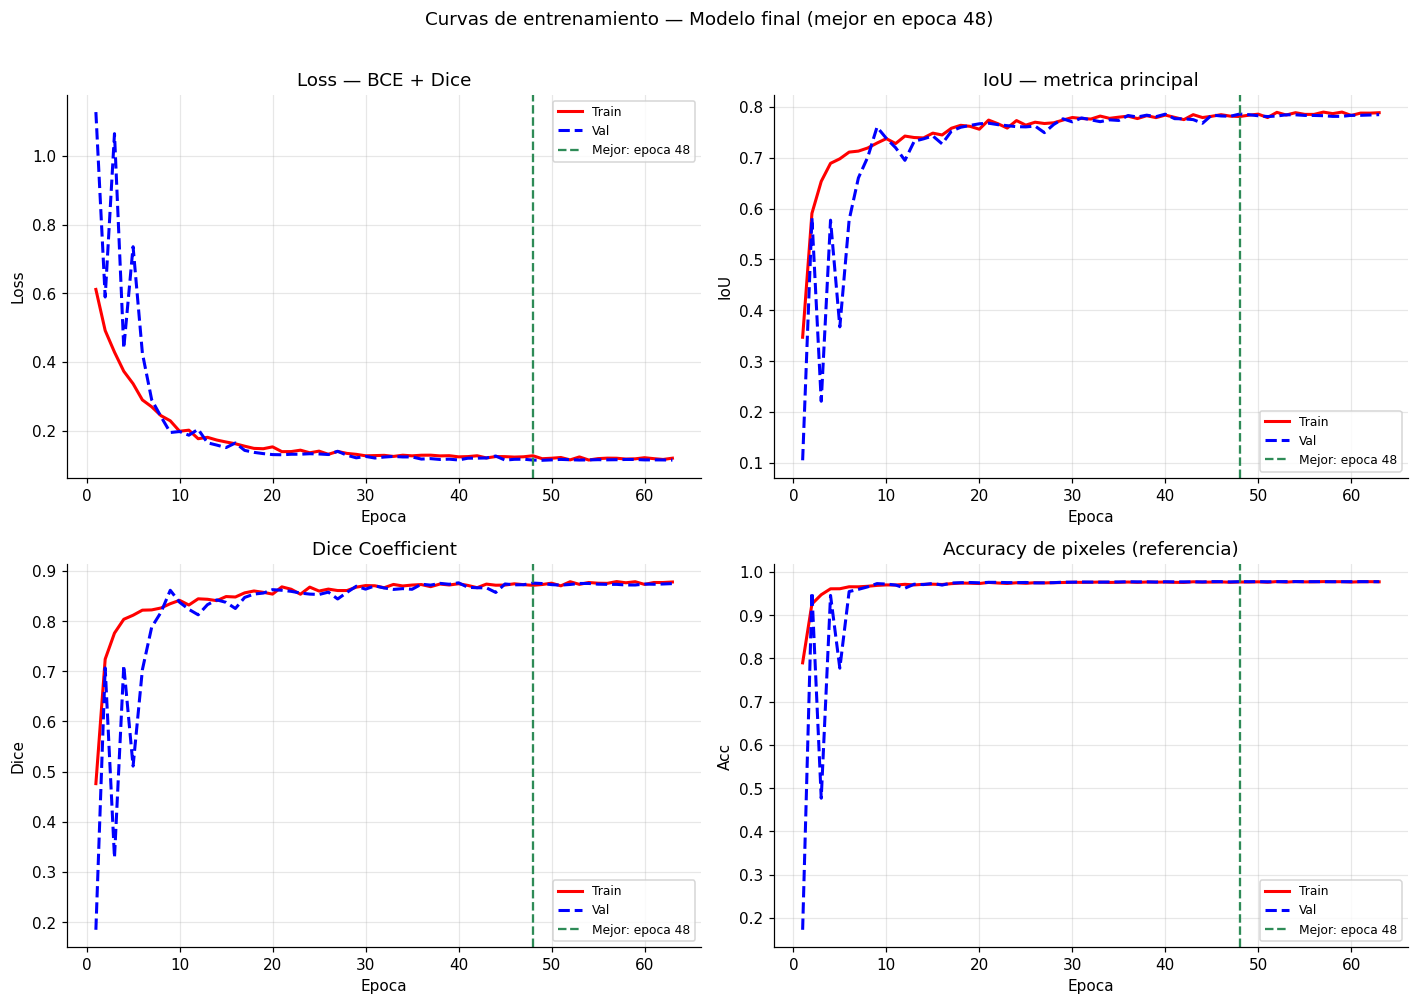

In [25]:
if len(img_paths) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    hist  = history_final.history
    ep_r  = range(1, len(hist['loss']) + 1)
    best_ep = np.argmax(hist['val_iou']) + 1

    for ax, (tk, vk), yl, tl in [
        (axes[0,0], ('loss',  'val_loss'),  'Loss',  'Loss — BCE + Dice'),
        (axes[0,1], ('iou',   'val_iou'),   'IoU',   'IoU — metrica principal'),
        (axes[1,0], ('dice',  'val_dice'),  'Dice',  'Dice Coefficient'),
        (axes[1,1], ('acc',   'val_acc'),   'Acc',   'Accuracy de pixeles (referencia)'),
    ]:
        ax.plot(ep_r, hist[tk], 'r-',  lw=2, label='Train')
        ax.plot(ep_r, hist[vk], 'b--', lw=2, label='Val')
        ax.axvline(best_ep, color='seagreen', lw=1.5, linestyle='--',
                   label=f'Mejor: epoca {best_ep}')
        ax.set_xlabel('Epoca'); ax.set_ylabel(yl)
        ax.set_title(tl); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.suptitle(f'Curvas de entrenamiento — Modelo final (mejor en epoca {best_ep})',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    guardar(fig, '07_training_curves')
    plt.show()



---



## 11. Evaluacion sobre el conjunto de test

In [26]:
def evaluar_modelo(modelo, ds_eval, umbral=None):
    """Evalua por imagen. umbral=None -> usa el MASK_THR global VIGENTE al llamar
    (la version anterior lo capturaba en la definicion y quedaba congelado en 0.5)."""
    if umbral is None:
        umbral = MASK_THR
    todas_iou, todos_dice, todos_acc = [], [], []
    imagenes, masks_true, masks_pred = [], [], []
    for batch_imgs, batch_masks in ds_eval:
        preds     = modelo.predict(batch_imgs, verbose=0)
        preds_bin = (preds > umbral).astype(np.float32)
        for i in range(len(batch_imgs)):
            m_t  = batch_masks[i].numpy().flatten().astype(int)
            m_p  = preds_bin[i].flatten().astype(int)
            inter = (m_t & m_p).sum()
            union = (m_t | m_p).sum()
            iou   = inter / union if union > 0 else 1.0
            dice  = 2*inter / (m_t.sum() + m_p.sum() + 1e-6)
            acc   = (m_t == m_p).mean()
            todas_iou.append(iou); todos_dice.append(dice); todos_acc.append(acc)
            imagenes.append(batch_imgs[i].numpy())
            masks_true.append(batch_masks[i].numpy())
            masks_pred.append(preds[i])
    return {
        'iou_mean': np.mean(todas_iou), 'dice_mean': np.mean(todos_dice),
        'acc_mean': np.mean(todos_acc), 'iou_per_img': todas_iou,
        'dice_per_img': todos_dice, 'umbral_usado': float(umbral),
        'imagenes': imagenes, 'masks_true': masks_true, 'masks_pred': masks_pred,
    }

def barrido_umbral(res, umbrales):
    """Recalcula IoU/Dice medios variando el umbral sobre probabilidades ya predichas."""
    ious_u, dices_u = {}, {}
    for u in umbrales:
        iou_v, dice_v = [], []
        for mt, mp in zip(res['masks_true'], res['masks_pred']):
            m_t = mt.flatten().astype(int)
            m_p = (mp.flatten() > u).astype(int)
            inter = (m_t & m_p).sum(); union = (m_t | m_p).sum()
            iou_v.append(inter/union if union > 0 else 1.0)
            dice_v.append(2*inter/(m_t.sum() + m_p.sum() + 1e-6))
        ious_u[float(u)]  = float(np.mean(iou_v))
        dices_u[float(u)] = float(np.mean(dice_v))
    return ious_u, dices_u

if len(img_paths) > 0:
    umbrales = np.arange(0.10, 0.95, 0.05)

    # ============ PASO 1 - SELECCION DEL UMBRAL: SOLO VALIDACION ============
    # El test NO se toca en este paso. Esto elimina el leakage de la version anterior,
    # que barria el umbral sobre eval_results del TEST y luego reportaba test.
    print('='*62)
    print('PASO 1 - Seleccion del umbral de decision SOBRE VALIDACION')
    print('='*62)
    eval_results_val   = evaluar_modelo(modelo_final, ds_val, umbral=0.5)
    ious_u_val, dices_u_val = barrido_umbral(eval_results_val, umbrales)
    umbral_opt_val = max(ious_u_val, key=ious_u_val.get)

    print(f'  N validacion: {len(eval_results_val["iou_per_img"])} imagenes')
    print(f"  {'umbral':>7} {'IoU val':>9} {'Dice val':>9}")
    print('  ' + '-'*28)
    for u in sorted(ious_u_val):
        marca = '  <== optimo' if abs(u - umbral_opt_val) < 1e-9 else ''
        print(f'  {u:>7.2f} {ious_u_val[u]:>9.4f} {dices_u_val[u]:>9.4f}{marca}')
    print()
    print(f'  Umbral optimo por IoU en VALIDACION: {umbral_opt_val:.2f} '
          f'(IoU val={ious_u_val[umbral_opt_val]:.4f}, Dice val={dices_u_val[umbral_opt_val]:.4f})')
    print(f'  Umbral estandar 0.50 en validacion:  IoU val={ious_u_val[min(ious_u_val, key=lambda x: abs(x-0.5))]:.4f}')

    # ---- SE FIJA EL UMBRAL. A partir de aca es una constante del sistema. ----
    MASK_THR = float(umbral_opt_val)
    print(f'\n  >>> MASK_THR FIJADO EN {MASK_THR:.2f} usando UNICAMENTE validacion.')
    print('  >>> El conjunto de test no participo de esta eleccion.')

    reg('umbral_seleccionado',            MASK_THR, dec=2)
    reg('umbral_iou_val_en_optimo',       ious_u_val[umbral_opt_val])
    reg('umbral_dice_val_en_optimo',      dices_u_val[umbral_opt_val])
    reg('umbral_iou_val_en_050',          ious_u_val[min(ious_u_val, key=lambda x: abs(x-0.5))])
    reg('n_val',  int(len(val_paths)))
    reg('n_train',int(len(train_paths)))
    reg('n_test', int(len(test_paths)))

    # ============ PASO 2 - REPORTE UNICO SOBRE TEST CON EL UMBRAL YA FIJADO ============
    print()
    print('='*62)
    print(f'PASO 2 - Evaluacion en TEST con el umbral fijado ({MASK_THR:.2f})')
    print('='*62)
    eval_results = evaluar_modelo(modelo_final, ds_test, umbral=MASK_THR)
    ious_arr = np.array(eval_results['iou_per_img'])

    print(f"  N test:              {len(ious_arr)}")
    print(f"  Umbral aplicado:     {eval_results['umbral_usado']:.2f}  (elegido en validacion)")
    print(f"  IoU medio:           {eval_results['iou_mean']:.4f}")
    print(f"  Dice medio:          {eval_results['dice_mean']:.4f}")
    print(f"  Accuracy pixeles:    {eval_results['acc_mean']:.4f}  (no usar como principal)")
    print()
    print(f'  IoU P10: {np.percentile(ious_arr,10):.4f}')
    print(f'  IoU P50: {np.percentile(ious_arr,50):.4f}')
    print(f'  IoU P90: {np.percentile(ious_arr,90):.4f}')
    buenos  = (ious_arr > 0.7).sum()
    aceptab = (ious_arr > 0.5).sum()
    n_t     = len(ious_arr)
    print(f'  Imagenes IoU > 0.7: {buenos}/{n_t} ({buenos/n_t*100:.1f}%)')
    print(f'  Imagenes IoU > 0.5: {aceptab}/{n_t} ({aceptab/n_t*100:.1f}%)')
    print()
    print(f"  Nota: accuracy={eval_results['acc_mean']:.4f} >> IoU={eval_results['iou_mean']:.4f}")
    print('  La brecha confirma que accuracy sobreestima el desempeno real.')

    reg('test_iou_medio',   eval_results['iou_mean'])
    reg('test_dice_medio',  eval_results['dice_mean'])
    reg('test_acc_pixel',   eval_results['acc_mean'])
    reg('test_iou_p10',     np.percentile(ious_arr,10))
    reg('test_iou_p50',     np.percentile(ious_arr,50))
    reg('test_iou_p90',     np.percentile(ious_arr,90))
    reg('test_pct_iou_mayor_07', buenos/n_t*100)
    reg('test_pct_iou_mayor_05', aceptab/n_t*100)


PASO 1 - Seleccion del umbral de decision SOBRE VALIDACION
  N validacion: 53 imagenes
   umbral   IoU val  Dice val
  ----------------------------
     0.10    0.7713    0.8664
     0.15    0.7767    0.8698
     0.20    0.7801    0.8720
     0.25    0.7824    0.8734
     0.30    0.7837    0.8742
     0.35    0.7843    0.8746
     0.40    0.7849    0.8749
     0.45    0.7853    0.8752  <== optimo
     0.50    0.7851    0.8750
     0.55    0.7847    0.8747
     0.60    0.7841    0.8743
     0.65    0.7829    0.8735
     0.70    0.7807    0.8720
     0.75    0.7779    0.8700
     0.80    0.7732    0.8668
     0.85    0.7654    0.8613
     0.90    0.7506    0.8504

  Umbral optimo por IoU en VALIDACION: 0.45 (IoU val=0.7853, Dice val=0.8752)
  Umbral estandar 0.50 en validacion:  IoU val=0.7851

  >>> MASK_THR FIJADO EN 0.45 usando UNICAMENTE validacion.
  >>> El conjunto de test no participo de esta eleccion.

PASO 2 - Evaluacion en TEST con el umbral fijado (0.45)
  N test:             

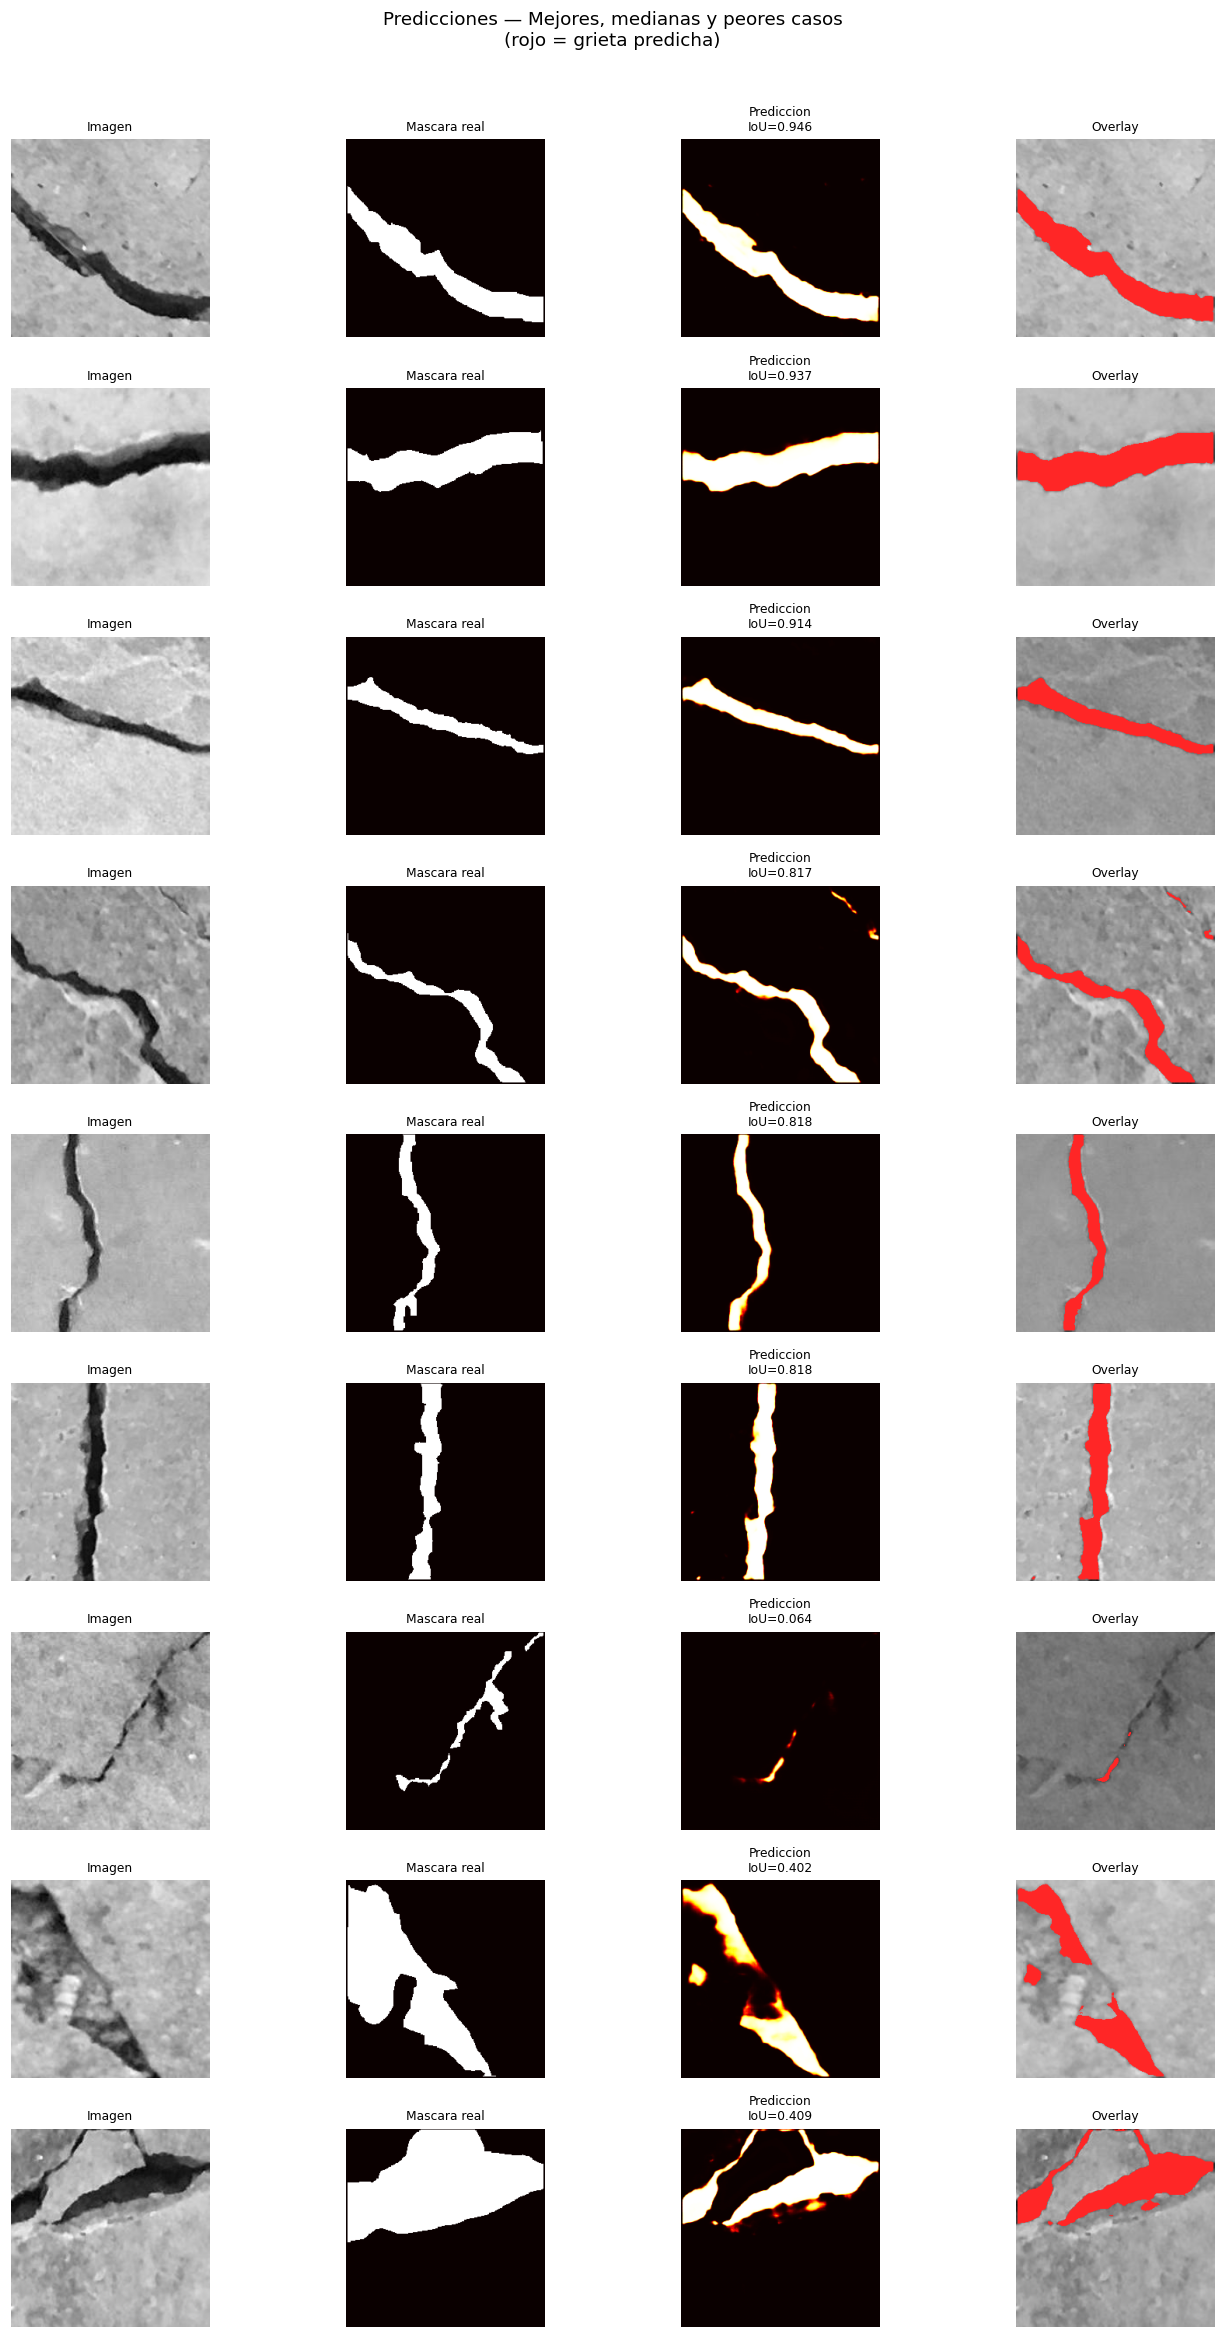

In [27]:
if len(img_paths) > 0:
    ious   = eval_results['iou_per_img']
    n_imgs = len(ious)
    idx_best  = np.argsort(ious)[-3:][::-1]
    idx_med   = np.argsort(ious)[n_imgs//2 - 1: n_imgs//2 + 2]
    idx_worst = np.argsort(ious)[:3]

    fig, axes = plt.subplots(9, 4, figsize=(13, 21))
    row = 0
    for indices, grupo in [
        (idx_best,  'MEJORES'),
        (idx_med,   'MEDIANAS'),
        (idx_worst, 'PEORES'),
    ]:
        for idx in list(indices)[:3]:
            img     = eval_results['imagenes'][idx][:,:,0]
            mt      = eval_results['masks_true'][idx][:,:,0]
            mp      = eval_results['masks_pred'][idx][:,:,0]
            iou_val = ious[idx]
            overlay = np.stack([img,img,img], axis=-1)
            pred_bin = (mp > MASK_THR)
            overlay[pred_bin, 0] = 1.0
            overlay[pred_bin, 1] = 0.15
            overlay[pred_bin, 2] = 0.15
            axes[row, 0].imshow(img, cmap='gray')
            axes[row, 0].set_title('Imagen', fontsize=8)
            axes[row, 1].imshow(mt, cmap='hot', vmin=0, vmax=1)
            axes[row, 1].set_title('Mascara real', fontsize=8)
            axes[row, 2].imshow(mp, cmap='hot', vmin=0, vmax=1)
            axes[row, 2].set_title(f'Prediccion\nIoU={iou_val:.3f}', fontsize=8)
            axes[row, 3].imshow(overlay)
            axes[row, 3].set_title('Overlay', fontsize=8)
            if idx == list(indices)[0]:
                axes[row, 0].set_ylabel(grupo, fontsize=8, rotation=0, labelpad=65, va='center')
            for ax in axes[row]: ax.axis('off')
            row += 1

    plt.suptitle('Predicciones — Mejores, medianas y peores casos\n'
                 '(rojo = grieta predicha)', fontsize=12, y=1.01)
    plt.tight_layout()
    guardar(fig, '08_predicciones')
    plt.show()


CRUCE - Auditoria de etiquetas  vs  IoU del modelo en test
  Imagenes de test: 62   (de 410 auditadas)
  Correlacion de Spearman IoU_modelo vs discordancia: -0.837
  (negativa = las imagenes peor etiquetadas son tambien las que el modelo falla)

  Top-10 peores IoU del modelo INTERSECADO con top-10 discordancia global: 3 imagen(es)
    ['01648', '03986', '05413']
  Top-10 peores IoU del modelo INTERSECADO con top-10 discordancia dentro de test: 9 imagen(es)
    ['00784', '01646', '01648', '01721', '03986', '05027', '05413', '06316', '06484']

  stem                      IoU_mod  IoUprx   contr  ratioG   score   flag
  ------------------------------------------------------------------------
  06484                      0.0636   0.264    35.5    0.76   0.736     SI
  06316                      0.4024   0.652    40.1    2.26   0.651     SI
  01648                      0.4090   0.379    39.6    2.69   1.098     SI
  03986                      0.5126   0.460    36.5    2.33   0.871     SI
 

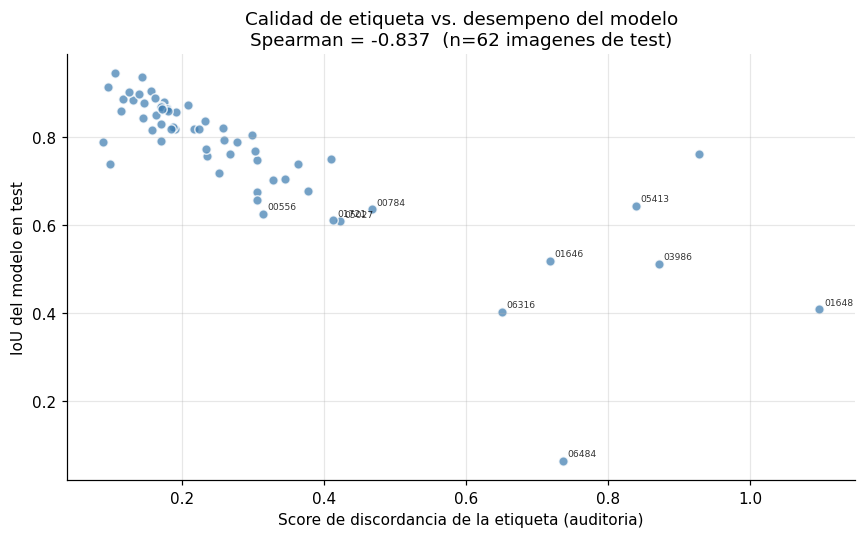

In [28]:
# ====== (d) CRUCE: candidatos a etiqueta ruidosa  x  peores IoU del modelo ======
# ds_test se construyo con shuffle=False, por lo que el i-esimo elemento de
# eval_results['iou_per_img'] corresponde a test_paths[i]. Esa es la clave del cruce.
if len(img_paths) > 0 and 'df_audit' in dir():
    ious_test = np.array(eval_results['iou_per_img'])
    assert len(ious_test) == len(test_paths), (
        f'Desalineacion: {len(ious_test)} predicciones vs {len(test_paths)} rutas de test. '
        'Verificar que ds_test se construyo con shuffle=False.')

    df_test = pd.DataFrame({
        'stem': [Path(p).stem for p in test_paths],
        'iou_modelo': ious_test,
    })
    df_cruce = df_test.merge(
        df_audit[['stem','iou_proxy','contraste','ratio_grosor','frac_mask','discordancia']],
        on='stem', how='left')
    df_cruce['rank_audit']  = df_cruce['discordancia'].rank(ascending=False)
    df_cruce['rank_modelo'] = df_cruce['iou_modelo'].rank(ascending=True)

    K = 10
    peores_modelo = set(df_cruce.nsmallest(K, 'iou_modelo')['stem'])
    peores_audit_global = set(df_audit.head(K)['stem'])           # top-10 global (410 img)
    peores_audit_test   = set(df_cruce.nlargest(K, 'discordancia')['stem'])  # top-10 dentro de test

    inter_global = peores_modelo & peores_audit_global
    inter_test   = peores_modelo & peores_audit_test

    rho = df_cruce[['iou_modelo','discordancia']].corr(method='spearman').iloc[0,1]

    print('='*70)
    print('CRUCE - Auditoria de etiquetas  vs  IoU del modelo en test')
    print('='*70)
    print(f'  Imagenes de test: {len(df_cruce)}   (de {len(df_audit)} auditadas)')
    print(f'  Correlacion de Spearman IoU_modelo vs discordancia: {rho:+.3f}')
    print(f'  (negativa = las imagenes peor etiquetadas son tambien las que el modelo falla)')
    print()
    print(f'  Top-{K} peores IoU del modelo INTERSECADO con top-{K} discordancia global: '
          f'{len(inter_global)} imagen(es)')
    if inter_global: print(f'    {sorted(inter_global)}')
    print(f'  Top-{K} peores IoU del modelo INTERSECADO con top-{K} discordancia dentro de test: '
          f'{len(inter_test)} imagen(es)')
    if inter_test: print(f'    {sorted(inter_test)}')
    print()
    print(f"  {'stem':<24} {'IoU_mod':>8} {'IoUprx':>7} {'contr':>7} {'ratioG':>7} "
          f"{'score':>7} {'flag':>6}")
    print('  ' + '-'*72)
    for _, r in df_cruce.nsmallest(K, 'iou_modelo').iterrows():
        flag = 'SI' if r['stem'] in (peores_audit_global | peores_audit_test) else '-'
        print(f"  {r['stem'][:24]:<24} {r['iou_modelo']:>8.4f} {r['iou_proxy']:>7.3f} "
              f"{r['contraste']:>7.1f} {r['ratio_grosor']:>7.2f} "
              f"{r['discordancia']:>7.3f} {flag:>6}")

    reg('cruce_spearman_iou_vs_discordancia', rho, dec=3)
    reg('cruce_n_interseccion_top10_global',  int(len(inter_global)))
    reg('cruce_n_interseccion_top10_test',    int(len(inter_test)))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(df_cruce['discordancia'], df_cruce['iou_modelo'],
               c='steelblue', s=38, alpha=0.75, edgecolor='white')
    for _, r in df_cruce.nsmallest(K, 'iou_modelo').iterrows():
        ax.annotate(r['stem'][:10], (r['discordancia'], r['iou_modelo']),
                    fontsize=6, alpha=0.8,
                    xytext=(3, 3), textcoords='offset points')
    ax.set_xlabel('Score de discordancia de la etiqueta (auditoria)')
    ax.set_ylabel('IoU del modelo en test')
    ax.set_title(f'Calidad de etiqueta vs. desempeno del modelo\n'
                 f'Spearman = {rho:+.3f}  (n={len(df_cruce)} imagenes de test)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    guardar(fig, '08b_cruce_auditoria_modelo')
    plt.show()
else:
    print('CRUCE NO EJECUTADO: falta df_audit (parche d) o el dataset no esta cargado.')



---



## 12. Optimizacion del umbral de decision

El modelo produce probabilidades por pixel entre 0 y 1. El umbral de binarizacion determina que pixeles se clasifican como grieta. El valor por defecto 0.5 no necesariamente maximiza IoU. En inspeccion estructural, el error mas costoso es no detectar una grieta (falso negativo), lo que favorece umbrales mas bajos a costa de mas falsos positivos.

El barrido se realiza **sobre el conjunto de validacion**. El umbral resultante se fija y recien entonces se evalua el test una unica vez. La curva de test se calcula a posteriori solo como diagnostico y no participo de la seleccion.


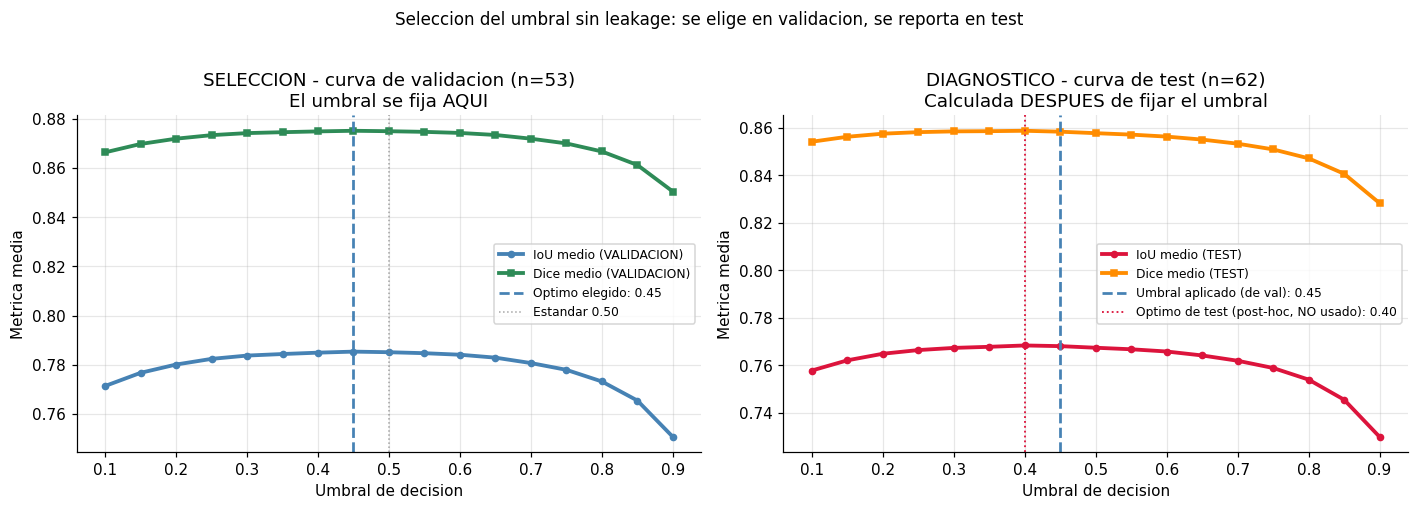

  Umbral elegido en VALIDACION:            0.45
  IoU en TEST con ese umbral:              0.7680
  Optimo post-hoc de TEST (NO utilizado):  0.40 (IoU=0.7683)
  Coste de NO mirar test:                  0.0003 IoU (0.03 pp) - magnitud del sesgo optimista que se evito.
  Este ultimo numero es la evidencia de que la seleccion fue honesta.


In [29]:
# ====== (a) DOS CURVAS: la de VALIDACION (que decidio) y la de TEST (diagnostico) ======
# La curva de test se calcula DESPUES de fijar el umbral y se muestra solo para evidenciar
# que la eleccion hecha en validacion no fue una eleccion sobre test. No se re-elige nada.
if len(img_paths) > 0:
    ious_u_test, dices_u_test = barrido_umbral(eval_results, umbrales)
    umbral_opt_test_posthoc   = max(ious_u_test, key=ious_u_test.get)   # SOLO informativo

    # Alias conservados para compatibilidad con celdas antiguas del notebook:
    ious_u, dices_u, umbral_opt = ious_u_val, dices_u_val, umbral_opt_val

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    ux = sorted(ious_u_val)
    axes[0].plot(ux, [ious_u_val[u]  for u in ux], 'steelblue', lw=2.5, marker='o',
                 ms=4, label='IoU medio (VALIDACION)')
    axes[0].plot(ux, [dices_u_val[u] for u in ux], 'seagreen', lw=2.5, marker='s',
                 ms=4, label='Dice medio (VALIDACION)')
    axes[0].axvline(umbral_opt_val, color='steelblue', lw=1.8, ls='--',
                    label=f'Optimo elegido: {umbral_opt_val:.2f}')
    axes[0].axvline(0.5, color='gray', lw=1, ls=':', alpha=0.7, label='Estandar 0.50')
    axes[0].set_title(f'SELECCION - curva de validacion (n={len(val_paths)})\n'
                      'El umbral se fija AQUI')
    axes[0].set_xlabel('Umbral de decision'); axes[0].set_ylabel('Metrica media')
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

    axes[1].plot(ux, [ious_u_test[u]  for u in ux], 'crimson', lw=2.5, marker='o',
                 ms=4, label='IoU medio (TEST)')
    axes[1].plot(ux, [dices_u_test[u] for u in ux], 'darkorange', lw=2.5, marker='s',
                 ms=4, label='Dice medio (TEST)')
    axes[1].axvline(umbral_opt_val, color='steelblue', lw=1.8, ls='--',
                    label=f'Umbral aplicado (de val): {umbral_opt_val:.2f}')
    axes[1].axvline(umbral_opt_test_posthoc, color='crimson', lw=1.2, ls=':',
                    label=f'Optimo de test (post-hoc, NO usado): {umbral_opt_test_posthoc:.2f}')
    axes[1].set_title(f'DIAGNOSTICO - curva de test (n={len(test_paths)})\n'
                      'Calculada DESPUES de fijar el umbral')
    axes[1].set_xlabel('Umbral de decision'); axes[1].set_ylabel('Metrica media')
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

    plt.suptitle('Seleccion del umbral sin leakage: se elige en validacion, se reporta en test',
                 fontsize=11, y=1.02)
    plt.tight_layout()
    guardar(fig, '09_threshold_val_vs_test')
    plt.show()

    coste = ious_u_test[umbral_opt_test_posthoc] - ious_u_test[umbral_opt_val]
    print(f'  Umbral elegido en VALIDACION:            {umbral_opt_val:.2f}')
    print(f'  IoU en TEST con ese umbral:              {ious_u_test[umbral_opt_val]:.4f}')
    print(f'  Optimo post-hoc de TEST (NO utilizado):  {umbral_opt_test_posthoc:.2f} '
          f'(IoU={ious_u_test[umbral_opt_test_posthoc]:.4f})')
    print(f'  Coste de NO mirar test:                  {coste:.4f} IoU '
          f'({coste*100:.2f} pp) - magnitud del sesgo optimista que se evito.')
    print('  Este ultimo numero es la evidencia de que la seleccion fue honesta.')

    reg('umbral_optimo_posthoc_test',   umbral_opt_test_posthoc, dec=2)
    reg('test_iou_en_umbral_val',       ious_u_test[umbral_opt_val])
    reg('test_iou_en_optimo_posthoc',   ious_u_test[umbral_opt_test_posthoc])
    reg('umbral_coste_no_mirar_test',   coste)



---



## 13. Impacto del data augmentation

Se compara el desempeno con y sin augmentation para cuantificar su contribucion en este dataset. Las transformaciones de color solo se aplican a la imagen; las geometricas se aplican sincronizadamente a imagen y mascara.


Entrenando sin augmentation...
Epoch 1/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 46s 505ms/step - acc: 0.7290 - dice: 0.4801 - iou: 0.3479 - loss: 0.6490 - val_acc: 0.8973 - val_dice: 0.0696 - val_iou: 0.0394 - val_loss: 0.7002 - learning_rate: 0.0010
Epoch 2/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - acc: 0.9228 - dice: 0.7135 - iou: 0.5805 - loss: 0.5293 - val_acc: 0.9048 - val_dice: 0.0672 - val_iou: 0.0419 - val_loss: 0.7258 - learning_rate: 0.0010
Epoch 3/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - acc: 0.9612 - dice: 0.8050 - iou: 0.6878 - loss: 0.4822 - val_acc: 0.8383 - val_dice: 0.4836 - val_iou: 0.3317 - val_loss: 0.6648 - learning_rate: 0.0010
Epoch 4/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - acc: 0.9654 - dice: 0.8188 - iou: 0.7077 - loss: 0.4480 - val_acc: 0.9594 - val_dice: 0.7474 - val_iou: 0.6232 - val_loss: 0.4904 - learning_rate: 0.0010
Epoch 5/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - acc: 0.9673 - dice: 0.8293 - iou: 0.7200 - loss: 0.4204 - val_acc: 0.9580 - val_dice: 

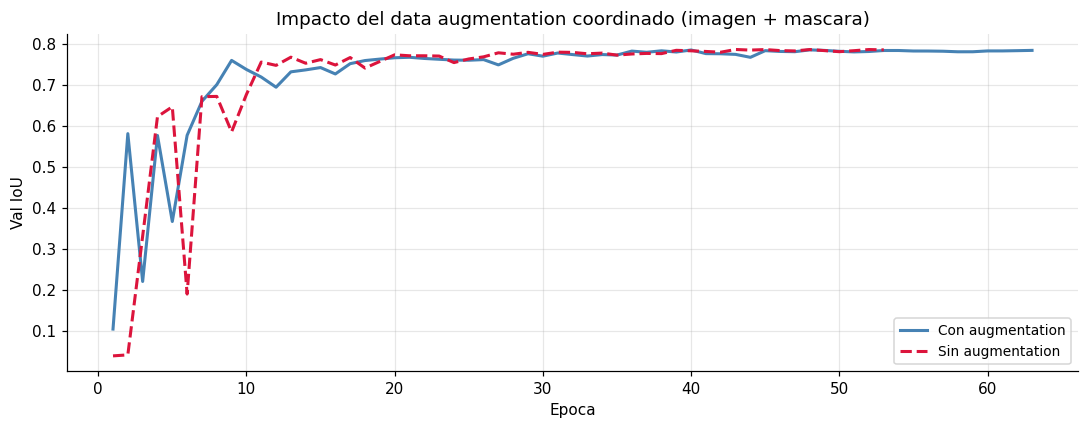

In [30]:
if len(img_paths) > 0:
    tf.random.set_seed(SEED)
    modelo_noaug = unet(filters_base=FB_FINAL, depth=DEPTH_FINAL, use_bn=True, dropout=0.1,
                        use_skip=True, nombre='noaug')
    ds_train_noaug = construir_dataset(train_paths, str(MASK_DIR),
                                       augment=False, shuffle=True)
    print('Entrenando sin augmentation...')
    hist_noaug, _ = compilar_y_entrenar(
        modelo_noaug, ds_train_noaug, ds_val, epochs=60, nombre='noaug')
    iou_noaug = max(hist_noaug.history['val_iou'])
    iou_aug   = max(history_final.history['val_iou'])
    print(f'\nCon augmentation:  val_IoU={iou_aug:.4f}')
    print(f'Sin augmentation:  val_IoU={iou_noaug:.4f}')
    print(f'Mejora absoluta:   {(iou_aug - iou_noaug)*100:+.1f} pp')

    fig, ax = plt.subplots(figsize=(10, 4))
    ep_aug   = range(1, len(history_final.history['val_iou'])+1)
    ep_noaug = range(1, len(hist_noaug.history['val_iou'])+1)
    ax.plot(ep_aug,   history_final.history['val_iou'], 'steelblue', lw=2,
            label='Con augmentation')
    ax.plot(ep_noaug, hist_noaug.history['val_iou'],    'crimson',   lw=2,
            label='Sin augmentation', linestyle='--')
    ax.set_xlabel('Epoca'); ax.set_ylabel('Val IoU')
    ax.set_title('Impacto del data augmentation coordinado (imagen + mascara)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    guardar(fig, '10_augmentation_impact')
    plt.show()



---



## 14. Generalizacion a imagenes externas (Mendeley)

Una señal critica de overfitting de dominio (data shift) es la degradacion del modelo al evaluar sobre imagenes capturadas con condiciones distintas al conjunto de entrenamiento: diferente iluminacion, escala de grietas, textura del hormigon o resolucion. Se aplica el modelo final sin reentrenamiento sobre imagenes del repositorio publico de Mendeley.

La diferencia entre el desempeno en el test set interno y en este conjunto externo cuantifica la brecha de generalizacion. Si el modelo fue entrenado sobre imagenes con condiciones de iluminacion o escala homogeneas, se espera una degradacion cuando estas condiciones cambian.


In [31]:
# ============ (b) DESCARGA REAL DEL DATASET DE MENDELEY ============
# Fuente: https://data.mendeley.com/datasets/5y9wdsg2zt/2
#   "Concrete Crack Images for Classification" (Ozgenel & Gonenc Sorguc, 2018)
#   40.000 imagenes 227x227 RGB en dos carpetas: Positive (con grieta) y Negative (sana).
# IMPORTANTE: este repositorio NO TIENE MASCARAS. Por lo tanto:
#   - en Positive la evaluacion es CUALITATIVA (distribucion del % de area predicha,
#     inspeccion de activaciones espurias). NO se puede calcular IoU ni Dice.
#   - en Negative se calcula una TASA DE FALSOS POSITIVOS, que es cuantitativa y es
#     el test mas informativo que permite este repositorio.
# Funciona en Colab y en local (Windows/Linux): la descarga usa urllib (portable) y
# solo cae a wget si urllib falla; las rutas cuelgan de BASE_DIR, no de /content.
import zipfile, shutil, hashlib

_BASE = Path(globals().get('BASE_DIR',
                           Path('/content') if Path('/content').is_dir() else Path.cwd()))

mendeley_dir = _BASE / 'mendeley_eval'
mendeley_dir.mkdir(exist_ok=True, parents=True)
N_MENDELEY   = 30       # imagenes por clase
MENDELEY_OK  = False    # bandera de seccion ejecutada / no ejecutada
MENDELEY_MOTIVO = ''

# URLs del cache publico de Mendeley Data. Se prueban en orden.
# Si Mendeley cambia el endpoint, descargar a mano el zip de la pagina del dataset y
# dejarlo en ZIP_LOCAL (ver ruta impresa mas abajo); el codigo lo detecta igual.
MENDELEY_URLS = [
    'https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/5y9wdsg2zt-2.zip',
    'https://md-datasets-cache-zipfiles-prod.s3.eu-west-1.amazonaws.com/5y9wdsg2zt-2.zip',
]
ZIP_LOCAL   = _BASE / '5y9wdsg2zt-2.zip'
EXTRACT_DIR = _BASE / 'mendeley_raw'

def _buscar_carpetas_clase(raiz):
    """Devuelve (dir_positive, dir_negative) buscando recursivamente, sin asumir la
    estructura interna del zip (que cambia entre versiones)."""
    pos = neg = None
    for d in raiz.rglob('*'):
        if d.is_dir():
            n = d.name.strip().lower()
            if n == 'positive' and pos is None: pos = d
            if n == 'negative' and neg is None: neg = d
    return pos, neg

pos_dir = neg_dir = None
try:
    if not (ZIP_LOCAL.exists() and ZIP_LOCAL.stat().st_size > 10_000_000):
        for url in MENDELEY_URLS:
            print(f'Descargando Mendeley desde: {url}')
            # _descargar() se definio en la celda de descarga del dataset (portable).
            ok = _descargar(url, ZIP_LOCAL, minimo_bytes=10_000_000)
            if ok:
                print(f'  OK: {ZIP_LOCAL.stat().st_size/1e6:.1f} MB descargados.')
                break
            print('  Fallo. Probando siguiente URL...')

    if ZIP_LOCAL.exists() and ZIP_LOCAL.stat().st_size > 10_000_000:
        EXTRACT_DIR.mkdir(exist_ok=True, parents=True)
        if not any(EXTRACT_DIR.iterdir()):
            print('Descomprimiendo (puede tardar 1-2 min)...')
            with zipfile.ZipFile(ZIP_LOCAL) as z:
                z.extractall(EXTRACT_DIR)
        pos_dir, neg_dir = _buscar_carpetas_clase(EXTRACT_DIR)
    else:
        MENDELEY_MOTIVO = 'no se pudo descargar el zip desde ninguna URL candidata'
except Exception as e:
    MENDELEY_MOTIVO = f'excepcion durante la descarga/descompresion: {type(e).__name__}: {e}'

mendeley_pos, mendeley_neg = [], []
if pos_dir is not None and neg_dir is not None:
    ext = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG')
    todas_pos, todas_neg = [], []
    for e in ext:
        todas_pos += sorted(glob.glob(str(pos_dir / e)))
        todas_neg += sorted(glob.glob(str(neg_dir / e)))
    todas_pos, todas_neg = sorted(set(todas_pos)), sorted(set(todas_neg))
    rng = np.random.RandomState(SEED)            # muestreo reproducible
    if len(todas_pos) >= 1 and len(todas_neg) >= 1:
        mendeley_pos = [todas_pos[i] for i in
                        rng.choice(len(todas_pos), min(N_MENDELEY, len(todas_pos)), replace=False)]
        mendeley_neg = [todas_neg[i] for i in
                        rng.choice(len(todas_neg), min(N_MENDELEY, len(todas_neg)), replace=False)]
        MENDELEY_OK = True
        print(f'\nMendeley disponible.')
        print(f'  Positive: {len(todas_pos):,} imagenes -> se muestrean {len(mendeley_pos)}')
        print(f'  Negative: {len(todas_neg):,} imagenes -> se muestrean {len(mendeley_neg)}')
        print(f'  Muestreo aleatorio reproducible con SEED={SEED}.')
    else:
        MENDELEY_MOTIVO = 'las carpetas Positive/Negative existen pero estan vacias'
elif not MENDELEY_MOTIVO:
    MENDELEY_MOTIVO = 'no se encontraron las carpetas Positive/Negative dentro del zip'

# --------- Compatibilidad con el resto del notebook + bandera de no ejecucion ---------
mendeley_imgs = list(mendeley_pos)
using_proxy   = not MENDELEY_OK     # NUNCA se sustituye por el test set en silencio

if not MENDELEY_OK:
    print('\n' + '!'*72)
    print('!! SECCION 14 (GENERALIZACION EXTERNA) - NO EJECUTADA')
    print(f'!! Motivo: {MENDELEY_MOTIVO}')
    print('!! NO se sustituye por el test set. En el informe esta seccion debe declararse')
    print('!! explicitamente como NO EJECUTADA; no puede afirmarse ningun resultado externo.')
    print('!! Alternativa manual: descargar el zip de')
    print('!!   https://data.mendeley.com/datasets/5y9wdsg2zt/2')
    print(f'!! y dejarlo en {ZIP_LOCAL} , luego reejecutar esta celda.')
    print('!'*72)

reg('mendeley_ejecutada',  bool(MENDELEY_OK))
reg('mendeley_n_positive', int(len(mendeley_pos)))
reg('mendeley_n_negative', int(len(mendeley_neg)))
if not MENDELEY_OK:
    reg('mendeley_motivo_no_ejecucion', MENDELEY_MOTIVO)


Descargando Mendeley desde: https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/5y9wdsg2zt-2.zip
  urllib fallo (HTTPError: HTTP Error 403: Forbidden); intentando wget...
  Fallo. Probando siguiente URL...
Descargando Mendeley desde: https://md-datasets-cache-zipfiles-prod.s3.eu-west-1.amazonaws.com/5y9wdsg2zt-2.zip
  urllib fallo (HTTPError: HTTP Error 301: Moved Permanently); intentando wget...
  Fallo. Probando siguiente URL...

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!! SECCION 14 (GENERALIZACION EXTERNA) - NO EJECUTADA
!! Motivo: no se pudo descargar el zip desde ninguna URL candidata
!! NO se sustituye por el test set. En el informe esta seccion debe declararse
!! explicitamente como NO EJECUTADA; no puede afirmarse ningun resultado externo.
!! Alternativa manual: descargar el zip de
!!   https://data.mendeley.com/datasets/5y9wdsg2zt/2
!! y dejarlo en /content/5y9wdsg2zt-2.zip , luego reejecutar esta celda.
!!!!!!!!!!!!!!!!!!!!!!!!

In [32]:
# ============ (b) EVALUACION EXTERNA SOBRE MENDELEY (sin reentrenamiento) ============
if not MENDELEY_OK:
    print('SECCION NO EJECUTADA - sin datos de Mendeley. No se produce ningun resultado.')
    print(f'Motivo: {MENDELEY_MOTIVO}')
    resultados_mendeley = None
else:
    TOL_FP = 0.005   # 0.5% del area: por debajo se considera "sin grieta detectada"

    def _predecir_lote(paths):
        """Devuelve (imgs, preds, pct_area) aplicando el modelo final SIN reentrenar."""
        imgs, preds, pct = [], [], []
        for p in paths:
            try:
                x = cargar_imagen(p, size=IMG_SIZE, grayscale=True)
            except Exception as e:
                print(f'  [omitida] {Path(p).name}: {e}'); continue
            pr = modelo_final.predict(x[np.newaxis, ...], verbose=0)[0]
            imgs.append(x); preds.append(pr)
            pct.append(float((pr[:, :, 0] > MASK_THR).mean() * 100))
        return imgs, preds, np.array(pct)

    print('Aplicando el modelo final (sin reentrenamiento) a Mendeley...')
    print(f'  Umbral usado: MASK_THR = {MASK_THR:.2f} (el elegido en validacion)')
    imgs_pos, preds_pos, pct_pos = _predecir_lote(mendeley_pos)
    imgs_neg, preds_neg, pct_neg = _predecir_lote(mendeley_neg)

    # Compatibilidad con nombres del notebook original
    imgs_externas, pred_externas = imgs_pos, preds_pos

    # ---------- Control de solapamiento con el entrenamiento ----------
    # Las imagenes de este trabajo son 227x227, igual que Mendeley: hay riesgo real de que
    # el dataset de segmentacion derive del mismo repositorio. Si hubiera solapamiento,
    # "generalizacion externa" seria una afirmacion invalida.
    def _ahash(path):
        g = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if g is None: return None
        g = cv2.resize(g, (8, 8), interpolation=cv2.INTER_AREA)
        return ''.join('1' if v > g.mean() else '0' for v in g.flatten())
    hashes_train = {h for h in (_ahash(p) for p in img_paths) if h}
    solapadas = sum(1 for p in (mendeley_pos + mendeley_neg)
                    if (_ahash(p) or '') in hashes_train)
    print(f'\n  Control de solapamiento (average hash 8x8) con las {len(img_paths)} '
          f'imagenes del dataset propio: {solapadas} coincidencia(s) '
          f'sobre {len(mendeley_pos)+len(mendeley_neg)} imagenes de Mendeley.')
    if solapadas > 0:
        print('  ADVERTENCIA: hay solapamiento. La evaluacion NO es estrictamente externa '
              'para esas imagenes; declararlo en el informe.')
    reg('mendeley_n_solapadas_con_dataset_propio', int(solapadas))

    # ---------- Positive: distribucion del % de area predicha ----------
    print('\n' + '='*66)
    print('MENDELEY - Positive (con grieta).  SIN MASCARAS -> evaluacion CUALITATIVA')
    print('='*66)
    print(f'  N = {len(pct_pos)} imagenes')
    print(f'  % area predicha:  media={pct_pos.mean():.2f}%  mediana={np.median(pct_pos):.2f}%')
    print(f'                    P10={np.percentile(pct_pos,10):.2f}%  '
          f'P90={np.percentile(pct_pos,90):.2f}%  min={pct_pos.min():.2f}%  '
          f'max={pct_pos.max():.2f}%')
    n_sin_deteccion = int((pct_pos < TOL_FP*100).sum())
    print(f'  Imagenes con area predicha < {TOL_FP*100:.1f}% (grieta NO detectada): '
          f'{n_sin_deteccion}/{len(pct_pos)} ({n_sin_deteccion/len(pct_pos)*100:.1f}%) '
          f'-> tasa de FALSOS NEGATIVOS a nivel de imagen')
    print(f'  Referencia interna: % de grieta medio del dataset propio = '
          f'{crack_fracs.mean()*100:.2f}%')

    # ---------- Negative: tasa de falsos positivos (lo cuantitativo) ----------
    print('\n' + '='*66)
    print('MENDELEY - Negative (superficie sana).  CONTROL DE FALSOS POSITIVOS')
    print('='*66)
    print(f'  N = {len(pct_neg)} imagenes')
    print(f'  % area predicha:  media={pct_neg.mean():.2f}%  mediana={np.median(pct_neg):.2f}%'
          f'  max={pct_neg.max():.2f}%')
    fp_img = int((pct_neg >= TOL_FP*100).sum())
    tasa_fp = fp_img/len(pct_neg)*100
    print(f'  Imagenes con area predicha >= {TOL_FP*100:.1f}%: {fp_img}/{len(pct_neg)} '
          f'-> TASA DE FALSOS POSITIVOS a nivel de imagen = {tasa_fp:.1f}%')
    print(f'  Activacion espuria media sobre superficie sana: {pct_neg.mean():.2f}% del area.')
    peores_fp = np.argsort(-pct_neg)[:5]
    print(f'  Casos de mayor activacion espuria (top 5): '
          f'{[f"{pct_neg[i]:.2f}%" for i in peores_fp]}')

    print('\n  ACLARACION METODOLOGICA: el repositorio de Mendeley NO incluye mascaras de')
    print('  segmentacion, por lo que NO es posible calcular IoU ni Dice sobre estas')
    print('  imagenes. Lo reportado es (1) la distribucion del % de area predicha en')
    print('  Positive, (2) inspeccion visual de activaciones espurias y (3) la tasa de')
    print('  falsos positivos en Negative, que si es cuantitativa.')

    resultados_mendeley = {
        'pct_pos': pct_pos, 'pct_neg': pct_neg,
        'tasa_fp_negative': tasa_fp, 'n_sin_deteccion_pos': n_sin_deteccion,
    }
    reg('mendeley_pct_area_pos_media',    pct_pos.mean())
    reg('mendeley_pct_area_pos_mediana',  float(np.median(pct_pos)))
    reg('mendeley_pct_area_pos_p10',      float(np.percentile(pct_pos,10)))
    reg('mendeley_pct_area_pos_p90',      float(np.percentile(pct_pos,90)))
    reg('mendeley_pct_area_neg_media',    pct_neg.mean())
    reg('mendeley_pct_area_neg_max',      float(pct_neg.max()))
    reg('mendeley_tasa_falsos_positivos_pct', tasa_fp)
    reg('mendeley_falsos_negativos_img_pct',  n_sin_deteccion/len(pct_pos)*100)
    reg('mendeley_tolerancia_area_pct',       TOL_FP*100, dec=2)

    # ---------- Figura 1: distribuciones ----------
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    axes[0].hist(pct_pos, bins=20, color='steelblue', edgecolor='white', alpha=0.9)
    axes[0].axvline(pct_pos.mean(), color='crimson', lw=2,
                    label=f'Media: {pct_pos.mean():.2f}%')
    axes[0].axvline(crack_fracs.mean()*100, color='seagreen', lw=2, ls='--',
                    label=f'Dataset propio: {crack_fracs.mean()*100:.2f}%')
    axes[0].set_xlabel('% de area predicha como grieta')
    axes[0].set_ylabel('Imagenes'); axes[0].set_title(f'Mendeley Positive (n={len(pct_pos)})')
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

    axes[1].hist(pct_neg, bins=20, color='darkorange', edgecolor='white', alpha=0.9)
    axes[1].axvline(TOL_FP*100, color='crimson', lw=2, ls='--',
                    label=f'Tolerancia FP: {TOL_FP*100:.1f}%')
    axes[1].set_xlabel('% de area predicha como grieta')
    axes[1].set_ylabel('Imagenes')
    axes[1].set_title(f'Mendeley Negative - control de FP (n={len(pct_neg)})\n'
                      f'Tasa de falsos positivos: {tasa_fp:.1f}%')
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
    plt.suptitle('Generalizacion a dominio externo (Mendeley 5y9wdsg2zt v2) - sin mascaras, '
                 'sin reentrenamiento', fontsize=11, y=1.03)
    plt.tight_layout()
    guardar(fig, '11_mendeley_distribuciones')
    plt.show()

    # ---------- Figura 2: casos cualitativos ----------
    top_pos = list(np.argsort(-pct_pos)[:3]) + list(np.argsort(pct_pos)[:3])   # mas y menos area
    top_neg = list(np.argsort(-pct_neg)[:4])                                    # peores espurias
    filas = ([('POS mayor area',  imgs_pos, preds_pos, pct_pos, i) for i in top_pos[:3]] +
             [('POS sin deteccion', imgs_pos, preds_pos, pct_pos, i) for i in top_pos[3:]] +
             [('NEG activacion espuria', imgs_neg, preds_neg, pct_neg, i) for i in top_neg])
    fig, axes = plt.subplots(len(filas), 3, figsize=(10, 3.0*len(filas)))
    for r, (etq, ims, prs, pcts, i) in enumerate(filas):
        im = ims[i][:, :, 0]; pr = prs[i][:, :, 0]
        ov = np.stack([im]*3, axis=-1).copy()
        ov[pr > MASK_THR] = [1.0, 0.15, 0.15]
        axes[r,0].imshow(im, cmap='gray'); axes[r,0].set_title(f'{etq}', fontsize=8)
        axes[r,1].imshow(pr, cmap='hot', vmin=0, vmax=1)
        axes[r,1].set_title(f'Probabilidad\narea={pcts[i]:.2f}%', fontsize=8)
        axes[r,2].imshow(ov); axes[r,2].set_title(f'Overlay (thr={MASK_THR:.2f})', fontsize=8)
        for ax in axes[r]: ax.axis('off')
    plt.suptitle('Mendeley - casos cualitativos: mayor area, no deteccion y activacion espuria\n'
                 'NO hay mascaras de referencia: no se puede calcular IoU', fontsize=10, y=1.01)
    plt.tight_layout()
    guardar(fig, '11b_mendeley_casos')
    plt.show()


SECCION NO EJECUTADA - sin datos de Mendeley. No se produce ningun resultado.
Motivo: no se pudo descargar el zip desde ninguna URL candidata



---



## 15. Viabilidad de despliegue en campo

Se estiman tres factores que determinan si el sistema puede operar en un dispositivo portatil (tablet, camara inteligente, computadora de borde):

1. **Numero de parametros**: determina el uso de memoria y el tamaño del modelo en disco.
2. **Resolucion de entrada**: a mayor resolucion, mayor costo computacional cuadratico.
3. **Latencia de inferencia**: tiempo por imagen en Colab (GPU T4) como cota inferior. En dispositivos de campo sin GPU dedicada la latencia se **estima** en ~20x la medida (supuesto declarado, no medido; ver el bloque ESTIMACIONES NO MEDIDAS de la celda siguiente).


In [33]:
# ============ (g) VIABILIDAD DE DESPLIEGUE - MEDIDO vs ESTIMADO ============
if len(img_paths) > 0:
    # ---- Convencion de tamano unica en todo el trabajo (definida en el parche P0) ----
    BYTES_POR_MB = 1e6           # 1 MB = 1e6 bytes (SI). NO 2**20 = 1.048.576.

    # ---- Supuestos declarados. Ninguno de estos fue medido. ----
    FACTOR_CPU_ARM        = 20   # latencia CPU ARM sin GPU / latencia T4  [SUPUESTO]
    FACTOR_TFLITE_TAMANO  = 4    # float32 -> int8: reduccion de tamano    [SUPUESTO]
    FACTOR_TFLITE_LATENC  = 5    # int8 en ARM / float32 en T4             [SUPUESTO]
    BYTES_POR_PARAM_FP32  = 4

    n_params  = modelo_final.count_params()
    tamano_mb = n_params * BYTES_POR_PARAM_FP32 / BYTES_POR_MB

    # ---- MEDICION REAL de latencia: batch=1, 50 repeticiones, con calentamiento ----
    img_dummy = np.random.rand(1, IMG_SIZE, IMG_SIZE, N_CHANNELS).astype(np.float32)
    _ = modelo_final.predict(img_dummy, verbose=0)          # warmup
    tiempos = []
    for _ in range(50):
        t0 = time.time()
        modelo_final.predict(img_dummy, verbose=0)
        tiempos.append(time.time() - t0)
    lat_ms  = float(np.mean(tiempos) * 1000)
    lat_p95 = float(np.percentile(tiempos, 95) * 1000)

    print('='*70)
    print('ANALISIS DE VIABILIDAD DE DESPLIEGUE')
    print(f'  Convencion de tamano: 1 MB = {BYTES_POR_MB:.0e} bytes (SI), '
          f'usada en TODO el trabajo.')
    print('='*70)
    print('\n--- VALORES MEDIDOS EN ESTA EJECUCION ---')
    print(f'  Hardware detectado:         {ACELERADOR}')
    print(f'  Parametros totales:         {n_params:,}')
    print(f'  Tamano modelo (float32):    {tamano_mb:.2f} MB   '
          f'({n_params:,} x {BYTES_POR_PARAM_FP32} B / {BYTES_POR_MB:.0e})')
    print(f'  Resolucion de entrada:      {IMG_SIZE}x{IMG_SIZE}x{N_CHANNELS}')
    print(f'  Latencia media (batch=1):   {lat_ms:.1f} ms/imagen  (50 repeticiones + warmup)')
    print(f'  Latencia P95:               {lat_p95:.1f} ms/imagen')
    print(f'  Throughput medido:          {1000/lat_ms:.1f} imagenes/s')

    lat_campo    = lat_ms * FACTOR_CPU_ARM
    tflite_mb    = tamano_mb / FACTOR_TFLITE_TAMANO
    tflite_lat   = lat_ms * FACTOR_TFLITE_LATENC
    print('\n--- ESTIMACIONES NO MEDIDAS (supuestos de literatura, sin verificacion empirica) ---')
    print(f'  [ESTIMACION NO MEDIDA] Latencia en campo (CPU ARM, sin GPU):')
    print(f'      supuesto: factor {FACTOR_CPU_ARM}x sobre la latencia medida en '
          f'{ACELERADOR}')
    print(f'      ~{lat_campo:.0f} ms/imagen  ->  ~{1000/lat_campo:.2f} imagenes/s')
    print(f'  [ESTIMACION NO MEDIDA] Modelo TFLite int8:')
    print(f'      supuesto: factor {FACTOR_TFLITE_TAMANO}x de reduccion de tamano '
          f'(float32 -> int8)')
    print(f'      tamano ~{tflite_mb:.2f} MB')
    print(f'      supuesto: factor {FACTOR_TFLITE_LATENC}x sobre la latencia medida')
    print(f'      latencia en campo ~{tflite_lat:.0f} ms/imagen')
    print('      NO se ejecuto conversion a TFLite ni benchmark en dispositivo real.')
    print('      Verificar antes de citar estos numeros como resultado.')

    print('\n--- CONCLUSION ---')
    if lat_campo < 2000:
        print(f'  Con el supuesto de {FACTOR_CPU_ARM}x, la latencia estimada '
              f'({lat_campo:.0f} ms) es compatible con inspeccion en campo por lotes,')
        print('  no con operacion en tiempo real estricto. Conclusion condicionada al supuesto.')
    else:
        print(f'  Con el supuesto de {FACTOR_CPU_ARM}x la latencia estimada '
              f'({lat_campo:.0f} ms) es elevada;')
        print('  se recomienda cuantizacion int8 y verificacion empirica en el dispositivo.')

    factor = FACTOR_CPU_ARM   # alias conservado para compatibilidad

    reg('deploy_params',                    int(n_params))
    reg('deploy_tamano_mb_fp32',            tamano_mb, dec=2)
    reg('deploy_latencia_media_ms_MEDIDA',  lat_ms, dec=1)
    reg('deploy_latencia_p95_ms_MEDIDA',    lat_p95, dec=1)
    reg('deploy_throughput_img_s_MEDIDO',   1000/lat_ms, dec=2)
    reg('deploy_hardware_medicion',         ACELERADOR)
    reg('deploy_factor_cpu_arm_SUPUESTO',   FACTOR_CPU_ARM)
    reg('deploy_latencia_campo_ms_ESTIMADA',lat_campo, dec=0)
    reg('deploy_tflite_factor_tamano_SUPUESTO',   FACTOR_TFLITE_TAMANO)
    reg('deploy_tflite_factor_latencia_SUPUESTO', FACTOR_TFLITE_LATENC)
    reg('deploy_tflite_mb_ESTIMADO',        tflite_mb, dec=2)
    reg('deploy_tflite_latencia_ms_ESTIMADA', tflite_lat, dec=0)
    reg('deploy_bytes_por_mb',              BYTES_POR_MB, dec=0)


ANALISIS DE VIABILIDAD DE DESPLIEGUE
  Convencion de tamano: 1 MB = 1e+06 bytes (SI), usada en TODO el trabajo.

--- VALORES MEDIDOS EN ESTA EJECUCION ---
  Hardware detectado:         GPU: Tesla T4
  Parametros totales:         488,617
  Tamano modelo (float32):    1.95 MB   (488,617 x 4 B / 1e+06)
  Resolucion de entrada:      256x256x1
  Latencia media (batch=1):   68.1 ms/imagen  (50 repeticiones + warmup)
  Latencia P95:               75.6 ms/imagen
  Throughput medido:          14.7 imagenes/s

--- ESTIMACIONES NO MEDIDAS (supuestos de literatura, sin verificacion empirica) ---
  [ESTIMACION NO MEDIDA] Latencia en campo (CPU ARM, sin GPU):
      supuesto: factor 20x sobre la latencia medida en GPU: Tesla T4
      ~1362 ms/imagen  ->  ~0.73 imagenes/s
  [ESTIMACION NO MEDIDA] Modelo TFLite int8:
      supuesto: factor 4x de reduccion de tamano (float32 -> int8)
      tamano ~0.49 MB
      supuesto: factor 5x sobre la latencia medida
      latencia en campo ~340 ms/imagen
      NO 

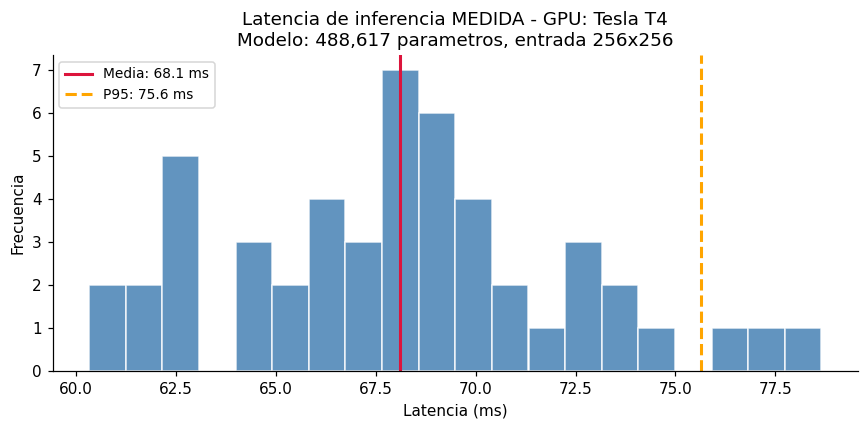

In [34]:
if len(img_paths) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(np.array(tiempos)*1000, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(lat_ms,  color='crimson', lw=2, label=f'Media: {lat_ms:.1f} ms')
    ax.axvline(lat_p95, color='orange',  lw=2, linestyle='--', label=f'P95: {lat_p95:.1f} ms')
    ax.set_xlabel('Latencia (ms)')
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'Latencia de inferencia MEDIDA - {ACELERADOR}\n'
                 f'Modelo: {n_params:,} parametros, entrada {IMG_SIZE}x{IMG_SIZE}')
    ax.legend(fontsize=9)
    plt.tight_layout()
    guardar(fig, '12_latencia')
    plt.show()



---



## 16. Cuantificacion de dano y uso operativo

El objetivo operativo del sistema no es solo detectar grietas sino cuantificar el dano para apoyar decisiones de mantenimiento. Se define una funcion que, dada la salida del modelo, calcula el porcentaje de area afectada y una clasificacion de severidad.


In [35]:
def calcular_dano(prediccion, umbral=MASK_THR, pixel_size_cm=0.1):
    mask_bin = (prediccion[:,:,0] > umbral).astype(np.uint8)
    pct_area = mask_bin.mean() * 100
    n_px     = mask_bin.sum()
    area_cm2 = n_px * (pixel_size_cm ** 2)
    severidad = 'grave' if pct_area > 10 else ('moderada' if pct_area > 3 else 'leve')
    return {'pct_afectado': pct_area, 'area_cm2': area_cm2,
            'n_pixeles': n_px, 'severidad': severidad}

if len(img_paths) > 0 and eval_results['masks_pred']:
    areas = [(i, calcular_dano(mp)['pct_afectado'])
             for i, mp in enumerate(eval_results['masks_pred'])]
    areas.sort(key=lambda x: -x[1])
    print('Cuantificacion de dano — ejemplos del test set:')
    print(f"  {'Imagen':>6}  {'Area (%)':.>12}  {'Severidad':>12}")
    print('  ' + '-'*34)
    for idx, area in areas[:8]:
        r = calcular_dano(eval_results['masks_pred'][idx])
        print(f"  {idx:>6}  {r['pct_afectado']:>11.2f}%  {r['severidad']:>12}")


Cuantificacion de dano — ejemplos del test set:
  Imagen  ....Area (%)     Severidad
  ----------------------------------
       4        28.42%         grave
      57        26.47%         grave
      14        21.93%         grave
      42        21.66%         grave
       5        15.35%         grave
      24        15.23%         grave
      17        14.15%         grave
       8        13.62%         grave


In [36]:
# ================== DIRECTIVA 0 - Serializacion de metricas ==================
# Recolecta lo que YA se calculo. No inventa claves: cada bloque esta protegido y
# solo escribe si la variable existe.
import json, os
from pathlib import Path

def _try(nombre, fn, dec=4):
    try:
        reg(nombre, fn(), dec=dec)
    except (NameError, KeyError, TypeError, IndexError, ValueError, AttributeError):
        pass

# --- Particiones exactas ---
_try('n_total_imagenes', lambda: int(len(img_paths)),   dec=0)
_try('n_train',          lambda: int(len(train_paths)), dec=0)
_try('n_val',            lambda: int(len(val_paths)),   dec=0)
_try('n_test',           lambda: int(len(test_paths)),  dec=0)
_try('img_size',         lambda: int(IMG_SIZE),         dec=0)
_try('batch_size',       lambda: int(BATCH_SIZE),       dec=0)
_try('n_channels',       lambda: int(N_CHANNELS),       dec=0)

# --- Modelo final y entrenamiento ---
_try('modelo_final_params',     lambda: int(modelo_final.count_params()), dec=0)
_try('modelo_final_epocas',     lambda: int(len(history_final.history['loss'])), dec=0)
_try('modelo_final_mejor_epoca',lambda: int(np.argmax(history_final.history['val_iou'])+1), dec=0)
_try('modelo_final_max_val_iou',lambda: float(max(history_final.history['val_iou'])))
_try('modelo_final_max_val_dice',lambda: float(max(history_final.history['val_dice'])))
_try('modelo_final_tiempo_entrenamiento_s', lambda: float(t_total), dec=1)

# --- Augmentation ---
_try('aug_val_iou_con',  lambda: float(iou_aug))
_try('aug_val_iou_sin',  lambda: float(iou_noaug))
_try('aug_mejora_pp',    lambda: float((iou_aug - iou_noaug)*100), dec=2)

# --- Cuantificacion de dano ---
_try('dano_pct_area_medio_test',
     lambda: float(np.mean([calcular_dano(mp)['pct_afectado']
                            for mp in eval_results['masks_pred']])))
_try('dano_pct_area_max_test',
     lambda: float(np.max([calcular_dano(mp)['pct_afectado']
                           for mp in eval_results['masks_pred']])))

# --- Entorno y trazabilidad ---
T_TOTAL_NOTEBOOK = time.time() - T0_NOTEBOOK
METRICAS['tiempo_total_notebook_s']   = round(float(T_TOTAL_NOTEBOOK), 1)
METRICAS['tiempo_total_notebook_min'] = round(float(T_TOTAL_NOTEBOOK)/60.0, 2)
for k, v in ENTORNO.items():
    METRICAS[f'entorno_{k}'] = v

# --- Inventario de figuras generadas ---
figs_generadas = sorted(p.name for p in FIGS_DIR.glob('exp4_*.png'))
METRICAS['n_figuras_generadas'] = len(figs_generadas)
METRICAS['figuras_generadas']   = figs_generadas

# --- Escritura ---
OUT_JSON = Path('metricas_exp4.json')
with open(OUT_JSON, 'w', encoding='utf-8') as f:
    json.dump(METRICAS, f, indent=2, ensure_ascii=False, sort_keys=True)

print('='*70)
print(f'METRICAS SERIALIZADAS -> {OUT_JSON.resolve()}')
print('='*70)
print(f'  Claves totales: {len(METRICAS)}')
print(f'  Figuras en {FIGS_DIR}/ : {len(figs_generadas)} (200 dpi, bbox_inches=tight)')
for n in figs_generadas:
    print(f'    - {FIGS_DIR}/{n}')
print(f'  Tiempo total de ejecucion: {T_TOTAL_NOTEBOOK/60:.1f} min')
print()
print('--- CONTENIDO ---')
for k in sorted(METRICAS):
    if k == 'figuras_generadas':
        continue
    print(f'  {k:<46} : {METRICAS[k]}')

# Descarga automatica solo si estamos en Colab (en local no aplica).
try:
    from google.colab import files
    files.download(str(OUT_JSON))
except Exception:
    pass


METRICAS SERIALIZADAS -> /content/metricas_exp4.json
  Claves totales: 139
  Figuras en figs/ : 15 (200 dpi, bbox_inches=tight)
    - figs/exp4_01_eda_desbalance.png
    - figs/exp4_02_auditoria_visual.png
    - figs/exp4_02b_auditoria_etiquetas_top10.png
    - figs/exp4_02c_auditoria_indicadores.png
    - figs/exp4_03_rgb_vs_gray.png
    - figs/exp4_04_skip_vs_nosk.png
    - figs/exp4_05_capacidad_red.png
    - figs/exp4_05b_capacidad_filiformes.png
    - figs/exp4_06_loss_comparison.png
    - figs/exp4_07_training_curves.png
    - figs/exp4_08_predicciones.png
    - figs/exp4_08b_cruce_auditoria_modelo.png
    - figs/exp4_09_threshold_val_vs_test.png
    - figs/exp4_10_augmentation_impact.png
    - figs/exp4_12_latencia.png
  Tiempo total de ejecucion: 36.7 min

--- CONTENIDO ---
  audit_color_gris_equivalente                   : 101.6
  audit_color_margen_umbral100                   : 1.6
  audit_color_std_max_entre_mascaras             : 0.0
  audit_contraste_medio                 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


---

*Experiencia 4 — Segmentacion de grietas en estructuras de hormigon con U-Net.*